# Bab III — Metodologi Penelitian

Notebook ini mendokumentasikan seluruh pipeline eksperimen klasifikasi citra makanan berbasis **EfficientNetV2B0** pada dataset **Food-101**:

1. **Persiapan environment & dataset** — mount Google Drive, ekstrak arsip ke SSD lokal Colab untuk throughput I/O maksimal.
2. **Data loading pipeline** — pembagian *train/val/test* mengikuti **split resmi Food-101** (`meta/train.txt` + `meta/test.txt`), dengan validasi 10% distratifikasi dari train.
3. **Arsitektur model** — EfficientNetV2B0 *pretrained ImageNet* dengan *classification head* (GAP → BN → Dropout → Dense 101).
4. **Strategi training dua-tahap (two-stage fine-tuning)** — Stage 1 *frozen backbone* untuk memanaskan head, Stage 2 *unfrozen* dengan `WarmUpCosine` LR schedule.
5. **Evaluasi** — akurasi Top-1, Top-5, *precision/recall/F1* (macro & weighted), *confusion matrix* 101×101, peringkat akurasi per-kelas.
6. **Deployment** — konversi ke TensorFlow.js (quantisasi float16) untuk inferensi real-time di browser.


In [ ]:
# @title 1. Setup Environment, Hardware, Path & Ekstrak Dataset
import sys
import os
import gzip
import shutil
import tarfile
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from tensorflow.keras import mixed_precision

# Setup tampilan Pandas agar tabel rapi
pd.set_option('display.max_colwidth', None)
pd.set_option('display.precision', 4)

# --- A. Mount Drive ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- B. Setup Path ---
# Arsip dataset (.tar.gz) + output model tetap di Drive agar PERSISTEN
BASE_DIR = '/content/drive/MyDrive/Skripsi/Deep_Learning'
MODELS_DIR = os.path.join(BASE_DIR, 'models')
TARGZ_PATH = os.path.join(BASE_DIR, 'food-101.tar.gz')

# Hasil ekstrak dataset disimpan di SSD Lokal Google Colab (I/O sangat cepat)
# Membaca 101.000 gambar dari Drive akan jauh lebih lambat (bottleneck network).
LOCAL_ROOT = '/content'
TAR_PATH = os.path.join(LOCAL_ROOT, 'food-101.tar')
DATASET_PATH = os.path.join(LOCAL_ROOT, 'food-101')
IMAGE_DIR = os.path.join(DATASET_PATH, 'images')
META_DIR = os.path.join(DATASET_PATH, 'meta')

# Buat folder models di Drive jika belum ada
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

print(f"📂 BASE DIR (Drive)         : {BASE_DIR}")
print(f"📦 ARSIP .tar.gz (Drive)    : {TARGZ_PATH}")
print(f"💾 DATASET DIR (SSD Lokal)  : {DATASET_PATH}")
print(f"🗄️ MODELS DIR (Drive)       : {MODELS_DIR}")

# --- C. Ekstrak Dataset ke SSD Lokal Colab ---
def extract_dataset():
    """
    Alur:
      1. food-101.tar.gz (di Drive)  --(gunzip)-->  /content/food-101.tar
      2. /content/food-101.tar       --(untar)-->   /content/food-101/{images,meta}/
    Hasil akhir: dataset berada di SSD lokal Colab, BUKAN di Drive.
    """
    # Skip jika dataset sudah diekstrak penuh di SSD lokal
    if os.path.exists(IMAGE_DIR) and len(os.listdir(IMAGE_DIR)) >= 101:
        num_folders = len(os.listdir(IMAGE_DIR))
        print(f"\n✅ Dataset sudah tersedia di SSD lokal: {IMAGE_DIR}")
        print(f"📊 Jumlah Kelas Terdeteksi: {num_folders}")
        return

    # Validasi arsip .tar.gz ada di Drive
    if not os.path.exists(TARGZ_PATH):
        raise FileNotFoundError(
            f"❌ Arsip tidak ditemukan: {TARGZ_PATH}\n"
            f"   Pastikan food-101.tar.gz sudah diupload ke {BASE_DIR}"
        )

    # Step 1: Ekstrak .tar.gz -> .tar (di SSD lokal)
    if not os.path.exists(TAR_PATH):
        print(f"\n📦 [1/2] Ekstrak .tar.gz -> .tar di SSD lokal Colab...")
        print(f"   Source : {TARGZ_PATH}")
        print(f"   Target : {TAR_PATH}")
        with gzip.open(TARGZ_PATH, 'rb') as f_in:
            with open(TAR_PATH, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out, length=16 * 1024 * 1024)
        print(f"✅ Selesai: {TAR_PATH} ({os.path.getsize(TAR_PATH) / (1024**3):.2f} GB)")
    else:
        print(f"\n📦 [1/2] .tar sudah ada di SSD lokal: {TAR_PATH}")

    # Step 2: Ekstrak .tar -> folder food-101/ (di SSD lokal)
    print(f"\n📦 [2/2] Ekstrak .tar -> {DATASET_PATH} (SSD lokal)...")
    with tarfile.open(TAR_PATH, 'r') as tar:
        tar.extractall(path=LOCAL_ROOT)
    print(f"✅ Ekstraksi selesai di SSD lokal.")

    # Hapus file .tar perantara untuk hemat ruang SSD
    try:
        os.remove(TAR_PATH)
        print(f"🧹 File perantara dihapus: {TAR_PATH}")
    except Exception as e:
        print(f"⚠️ Gagal hapus .tar: {e}")

    # Validasi hasil
    if os.path.exists(IMAGE_DIR):
        num_folders = len(os.listdir(IMAGE_DIR))
        print(f"\n✅ Dataset siap di SSD lokal: {IMAGE_DIR}")
        print(f"📊 Jumlah Kelas Terdeteksi: {num_folders}")
    else:
        print(f"❌ ERROR: {IMAGE_DIR} tidak ditemukan setelah ekstraksi.")

extract_dataset()

# --- D. Hardware Check & Optimization ---
def setup_hardware():
    print("\n🚀 MEMERIKSA HARDWARE & KONFIGURASI...")
    try:
        # Mixed Precision untuk efisiensi tinggi (Mempercepat training)
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed Precision Aktif: {policy.compute_dtype}")

        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            try:
                gpu_name = !nvidia-smi --query-gpu=gpu_name --format=csv,noheader
                print(f"✅ GPU Terdeteksi: {gpu_name[0]}")
            except:
                print("✅ GPU Terdeteksi (Detail nama tidak dapat diambil)")
            strategy = tf.distribute.MirroredStrategy()
        else:
            print("⚠️ GPU Tidak Terdeteksi. Training akan sangat lambat.")
            strategy = tf.distribute.get_strategy()
    except Exception as e:
        print(f"⚠️ Warning pada setup GPU: {e}")
        strategy = tf.distribute.get_strategy()

    print("\n🔰 SISTEM SIAP.")
    return strategy

strategy = setup_hardware()


Mounted at /content/drive
📂 BASE DIR (Drive)         : /content/drive/MyDrive/Skripsi/Deep_Learning
📦 ARSIP .tar.gz (Drive)    : /content/drive/MyDrive/Skripsi/Deep_Learning/food-101.tar.gz
💾 DATASET DIR (SSD Lokal)  : /content/food-101
🗄️ MODELS DIR (Drive)       : /content/drive/MyDrive/Skripsi/Deep_Learning/models

📦 [1/2] Ekstrak .tar.gz -> .tar di SSD lokal Colab...
   Source : /content/drive/MyDrive/Skripsi/Deep_Learning/food-101.tar.gz
   Target : /content/food-101.tar
✅ Selesai: /content/food-101.tar (4.84 GB)

📦 [2/2] Ekstrak .tar -> /content/food-101 (SSD lokal)...


/tmp/ipykernel_488/868805035.py:83: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=LOCAL_ROOT)


✅ Ekstraksi selesai di SSD lokal.
🧹 File perantara dihapus: /content/food-101.tar

✅ Dataset siap di SSD lokal: /content/food-101/images
📊 Jumlah Kelas Terdeteksi: 101

🚀 MEMERIKSA HARDWARE & KONFIGURASI...
✅ Mixed Precision Aktif: float16
✅ GPU Terdeteksi: NVIDIA A100-SXM4-80GB

🔰 SISTEM SIAP.


In [ ]:
# @title 2. Data Loading Pipeline (Split Resmi Food-101)
import tensorflow as tf
import os
import random
from sklearn.model_selection import train_test_split

# --- KONFIGURASI ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

# Reprodusibilitas: set seed global
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"⚙️ PIPELINE CONFIG:")
print(f"   Image Size : {IMG_SIZE}")
print(f"   Batch Size : {BATCH_SIZE}")
print(f"   Seed       : {SEED}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Folder images tidak ditemukan di: {IMAGE_DIR}")

# --- A. BACA SPLIT RESMI FOOD-101 (meta/train.txt & meta/test.txt) ---
def load_split(split_file):
    """Baca file split resmi. Format tiap baris: 'apple_pie/1005649' (tanpa .jpg)."""
    path = os.path.join(META_DIR, split_file)
    with open(path, 'r') as f:
        entries = [line.strip() for line in f if line.strip()]
    file_paths = [os.path.join(IMAGE_DIR, e + '.jpg') for e in entries]
    labels = [e.split('/')[0] for e in entries]
    return file_paths, labels

print("\n📂 Membaca split resmi Food-101...")
train_paths_full, train_labels_full = load_split('train.txt')
test_paths, test_labels_str = load_split('test.txt')
print(f"   train.txt : {len(train_paths_full):>6} sampel")
print(f"   test.txt  : {len(test_paths):>6} sampel")

# --- B. DAFTAR KELAS (urutan alfabet, konsisten dengan standar Keras) ---
loaded_class_names = sorted(set(train_labels_full))
num_classes = len(loaded_class_names)
class_to_idx = {c: i for i, c in enumerate(loaded_class_names)}
print(f"📊 Total Kelas : {num_classes}")

# Konversi label string → indeks integer
train_labels_full_idx = [class_to_idx[l] for l in train_labels_full]
test_labels = [class_to_idx[l] for l in test_labels_str]

# --- C. PISAH: TRAIN 90% + VAL 10% (STRATIFIED) ---
# Val HANYA dari train.txt → test.txt benar-benar held-out untuk evaluasi final
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_full, train_labels_full_idx,
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels_full_idx
)
print(f"\n📦 HASIL SPLIT FINAL:")
print(f"   Train : {len(train_paths):>6} sampel  (90% dari train.txt)")
print(f"   Val   : {len(val_paths):>6} sampel  (10% dari train.txt → EarlyStopping/Checkpoint)")
print(f"   Test  : {len(test_paths):>6} sampel  (test.txt → HELD-OUT, hanya evaluasi final)")

# --- D. VALIDASI INTEGRITAS DATASET ---
# Cegah crash mid-training karena file korup / ekstraksi tidak sempurna
print("\n🔍 Validasi Integritas Dataset Food-101...")
EXPECTED_TRAIN = 75750
EXPECTED_TEST = 25250
EXPECTED_CLASSES = 101

assert len(train_paths_full) == EXPECTED_TRAIN, \
    f"train.txt harus {EXPECTED_TRAIN} sampel, ditemukan {len(train_paths_full)}"
assert len(test_paths) == EXPECTED_TEST, \
    f"test.txt harus {EXPECTED_TEST} sampel, ditemukan {len(test_paths)}"
assert num_classes == EXPECTED_CLASSES, \
    f"Jumlah kelas harus {EXPECTED_CLASSES}, ditemukan {num_classes}"

# Spot-check 5 file acak (3 train, 1 val, 1 test) benar-benar ada di disk
_check_paths = (
    random.sample(train_paths, 3)
    + random.sample(val_paths, 1)
    + random.sample(test_paths, 1)
)
for p in _check_paths:
    assert os.path.exists(p), f"File tidak ditemukan: {p}"

print(f"   ✅ Jumlah sampel   : {EXPECTED_TRAIN} train + {EXPECTED_TEST} test — SESUAI")
print(f"   ✅ Jumlah kelas    : {EXPECTED_CLASSES} — SESUAI")
print(f"   ✅ Spot-check 5 file acak: OK (semua ada di disk)")

# --- E. tf.data PIPELINE ---
AUTOTUNE = tf.data.AUTOTUNE

def _load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    label_onehot = tf.one_hot(label, num_classes)
    return img, label_onehot

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), list(labels)))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(paths), 10000),
                        seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

print("\n🔄 Membangun tf.data pipeline...")
train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_dataset(val_paths,   val_labels,   shuffle=False)
test_ds  = make_dataset(test_paths,  test_labels,  shuffle=False)
print("✅ Pipeline siap: train_ds, val_ds, test_ds")


⚙️ PIPELINE CONFIG:
   Image Size : (224, 224)
   Batch Size : 64
   Seed       : 42

📂 Membaca split resmi Food-101...
   train.txt :  75750 sampel
   test.txt  :  25250 sampel
📊 Total Kelas : 101

📦 HASIL SPLIT FINAL:
   Train :  68175 sampel  (90% dari train.txt)
   Val   :   7575 sampel  (10% dari train.txt → EarlyStopping/Checkpoint)
   Test  :  25250 sampel  (test.txt → HELD-OUT, hanya evaluasi final)

🔍 Validasi Integritas Dataset Food-101...
   ✅ Jumlah sampel   : 75750 train + 25250 test — SESUAI
   ✅ Jumlah kelas    : 101 — SESUAI
   ✅ Spot-check 5 file acak: OK (semua ada di disk)

🔄 Membangun tf.data pipeline...
✅ Pipeline siap: train_ds, val_ds, test_ds


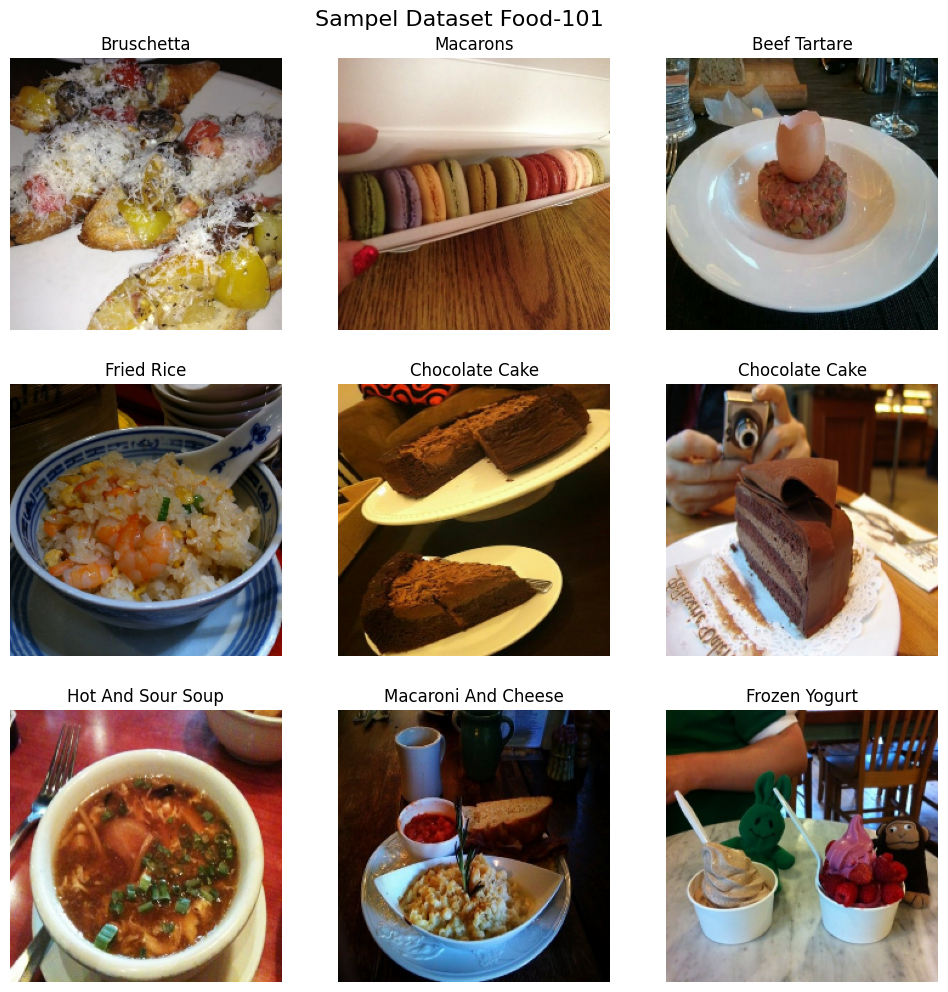

In [ ]:
# @title 3. Visualisasi Sampel Dataset
image_batch, label_batch = next(iter(train_ds))

plt.figure(figsize=(12, 12))
plt.suptitle("Sampel Dataset Food-101", fontsize=16, y=0.92)

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = image_batch[i].numpy().astype("uint8")
    plt.imshow(img)

    label_index = np.argmax(label_batch[i])
    class_name = loaded_class_names[label_index].replace("_", " ").title()

    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
# @title 4. Membangun Model Arsitektur (EfficientNetV2B0)
import tensorflow as tf

def build_model(num_classes):
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))

    # Augmentasi Ringan (hanya aktif saat training=True)
    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.1)(x)
    x = tf.keras.layers.RandomZoom(0.1)(x)

    # Base Model (EfficientNetV2B0, pretrained ImageNet)
    base_model = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        input_tensor=x,
        weights="imagenet"
    )

    # Stage 1: FREEZE backbone → hanya head yang dilatih (transfer learning)
    # Akan di-unfreeze pada Stage 2 untuk fine-tuning end-to-end
    base_model.trainable = False

    # Classification Head
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    full_model = tf.keras.Model(inputs, outputs, name="EfficientNetV2B0_Food101")
    return full_model, base_model

with strategy.scope():
    model, base_model = build_model(num_classes)

# Info params
total_params = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
frozen_params = total_params - trainable_params

print(f"✅ Model Arsitektur EfficientNetV2B0 Berhasil Dibangun untuk {num_classes} kelas.")
print(f"   - Total parameters       : {total_params:>12,}")
print(f"   - Trainable (Stage 1)    : {trainable_params:>12,}  (hanya head: BN + Dense)")
print(f"   - Frozen  (backbone)     : {frozen_params:>12,}  (di-unfreeze di Stage 2)")
model.summary(expand_nested=False, show_trainable=True)


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ Model Arsitektur EfficientNetV2B0 Berhasil Dibangun untuk 101 kelas.
   - Total parameters       :    6,053,813
   - Trainable (Stage 1)    :      131,941  (hanya head: BN + Dense)
   - Frozen  (backbone)     :    5,921,872  (di-unfreeze di Stage 2)


Model: "EfficientNetV2B0_Food101"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 224,     │         0 │ input_layer[0… │   -   │
│ (RandomFlip)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 224,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_zoom       │ (None, 224,     │         0 │ random_rotati… │   -   │
│ (RandomZoom)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 224,     │         0 │ random_zoom[0… │   -   │
│ (Rescaling)       │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ normalization     │ (None, 224,     │         0 │ rescaling[0][… │   -   │
│ (Normalization)   │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_conv         │ (None, 112,     │       864 │ normalization… │   N   │
│ (Conv2D)          │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_bn           │ (None, 112,     │       128 │ stem_conv[0][… │   N   │
│ (BatchNormalizat… │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ stem_activation   │ (None, 112,     │         0 │ stem_bn[0][0]  │   -   │
│ (Activation)      │ 112, 32)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 112,     │     4,608 │ stem_activati… │   N   │
│ (Conv2D)          │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 112,     │        64 │ block1a_proje… │   N   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block1a_project_… │ (None, 112,     │         0 │ block1a_proje… │   -   │
│ (Activation)      │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_expand_c… │ (None, 56, 56,  │     9,216 │ block1a_proje… │   N   │
│ (Conv2D)          │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_expand_bn │ (None, 56, 56,  │       256 │ block2a_expan… │   N   │
│ (BatchNormalizat… │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_expand_a… │ (None, 56, 56,  │         0 │ block2a_expan… │   -   │
│ (Activation)      │ 64)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_project_… │ (None, 56, 56,  │     2,048 │ block2a_expan… │   N   │
│ (Conv2D)          │ 32)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block2a_project_… │ (None, 56, 56,  │       128 │ block2a_proje… │   N 

 Total params: 6,053,813 (23.09 MB)

 Trainable params: 131,941 (515.39 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 3.5 Strategi Training — Stage 1: Transfer Learning (Frozen Backbone)

Stage pertama men-*freeze* seluruh backbone EfficientNetV2B0 (± 5,9 juta parameter) sehingga hanya *classification head* (BN + Dense 101) yang dilatih. Tujuannya adalah memberi head kesempatan "memanaskan" bobot acaknya dengan *learning rate* konstan yang relatif besar (`1e-3`) tanpa merusak fitur konvolusional hasil pretraining ImageNet. Tahap ini hanya butuh sedikit epoch (5) karena yang dioptimasi sangat sedikit.


In [ ]:
# @title 5. Optimizer & LR Scheduler — Stage 1: Frozen Backbone
import tensorflow as tf
import numpy as np

# --- A. WarmUpCosine LR Schedule (dipakai di Stage 2) ---
@tf.keras.utils.register_keras_serializable()
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total steps must be larger than warmup steps")
        lr = 0.5 * self.learning_rate_base * (1 + tf.cos(
            self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)))
        if self.warmup_steps > 0:
            slope = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)

    def get_config(self):
        return {
            'learning_rate_base': self.learning_rate_base,
            'total_steps': self.total_steps,
            'warmup_learning_rate': self.warmup_learning_rate,
            'warmup_steps': self.warmup_steps,
        }

# --- B. LearningRateLogger (catat LR efektif per epoch ke CSV) ---
class LearningRateLogger(tf.keras.callbacks.Callback):
    """Injeksi field 'lr' ke logs agar tercatat di CSVLogger."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if callable(lr):
            lr = lr(self.model.optimizer.iterations)
        logs['lr'] = float(tf.keras.backend.get_value(lr))

# --- C. Konfigurasi strategi two-stage fine-tuning ---
# Budget dinaikkan dari 15 → 50 epoch agar model tidak underfitting. EarlyStopping pada
# Stage 2 bertindak sebagai "rem otomatis" — memotong training bila val_accuracy
# sudah plateau, sehingga risiko overfitting tetap terkendali meski budget besar.
STAGE1_EPOCHS = 5        # Transfer learning: backbone frozen, hanya head dilatih (warm-up cepat)
STAGE2_EPOCHS = 45       # Fine-tuning end-to-end: budget besar; EarlyStopping (patience=8) memotong bila val_accuracy plateau
TOTAL_EPOCHS  = STAGE1_EPOCHS + STAGE2_EPOCHS   # Total 50 epoch (5 + 45)

print(f"🎯 TWO-STAGE FINE-TUNING STRATEGY")
print(f"   Stage 1 (Frozen)    : {STAGE1_EPOCHS} epoch → head only, LR konstan 1e-3")
print(f"   Stage 2 (Unfrozen)  : {STAGE2_EPOCHS} epoch → end-to-end, WarmUpCosine (base=1e-4) + EarlyStopping")
print(f"   Total budget        : {TOTAL_EPOCHS} epoch (EarlyStopping dapat menghentikan lebih awal bila val_accuracy plateau)")

# --- D. Compile Stage 1 — LR konstan, backbone masih frozen (dari Cell 4) ---
STAGE1_LR = 1e-3
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=STAGE1_LR, weight_decay=2e-5),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
        ],
        jit_compile=False,
    )

print(f"\n✅ Stage 1 compile selesai — LR = {STAGE1_LR}, jit_compile=False")
print(f"   Metrics: Accuracy, Top-5 Accuracy")


🎯 TWO-STAGE FINE-TUNING STRATEGY
   Stage 1 (Frozen)    : 5 epoch → head only, LR konstan 1e-3
   Stage 2 (Unfrozen)  : 45 epoch → end-to-end, WarmUpCosine (base=1e-4) + EarlyStopping
   Total budget        : 50 epoch (EarlyStopping dapat menghentikan lebih awal bila val_accuracy plateau)

✅ Stage 1 compile selesai — LR = 0.001, jit_compile=False
   Metrics: Accuracy, Top-5 Accuracy


In [ ]:
# @title 6. Training Stage 1 — Transfer Learning (Frozen Backbone)
import os
import tensorflow as tf

checkpoint_path  = os.path.join(MODELS_DIR, 'best_model_efficientnet.keras')
log_path         = os.path.join(MODELS_DIR, 'training_log.csv')

callbacks_s1 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1,
    ),
    LearningRateLogger(),
    tf.keras.callbacks.CSVLogger(log_path, append=False),
]

train_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"🚀 STAGE 1 TRAINING — {STAGE1_EPOCHS} epoch (backbone FROZEN, head only)")
print(f"   Trainable params: {train_params:,}")

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    callbacks=callbacks_s1,
    verbose=1,
)
print("\n✅ Stage 1 selesai.")

🚀 STAGE 1 TRAINING — 5 epoch (backbone FROZEN, head only)
   Trainable params: 131,941
Epoch 1/5
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3534 - loss: 2.8231 - top5_acc: 0.6050
Epoch 1: val_accuracy improved from None to 0.61650, saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_efficientnet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_efficientnet.keras
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 76s 53ms/step - accuracy: 0.4517 - loss: 2.2792 - top5_acc: 0.7184 - val_accuracy: 0.6165 - val_loss: 1.4980 - val_top5_acc: 0.8557 - lr: 0.0010
Epoch 2/5
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5580 - loss: 1.7582 - top5_acc: 0.8148
Epoch 2: val_accuracy improved from 0.61650 to 0.63393, saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_efficientnet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_eff

## 3.6 Strategi Training — Stage 2: Fine-Tuning End-to-End (Unfrozen Backbone)

Stage kedua me-*unfreeze* seluruh backbone dan melatih model end-to-end selama maksimum **45 epoch** (total 50 epoch bersama Stage 1) dengan *learning rate* jauh lebih kecil (`base=1e-4`) mengikuti skema `WarmUpCosine` (warm-up 10% steps → cosine decay ke 0 sepanjang 45 epoch). LR yang kecil menjaga agar fitur pretrained tidak rusak, sementara *cosine decay* yang “direntangkan” memastikan model tetap belajar di epoch-epoch akhir alih-alih membeku terlalu cepat seperti pada skema 10-epoch sebelumnya.

`EarlyStopping` (`monitor='val_accuracy'`, `patience=8`, `min_delta=0.001`, `restore_best_weights=True`) bertindak sebagai “rem otomatis”: jika akurasi validasi tidak meningkat ≥ 0.1% selama 8 epoch berturut-turut, training dihentikan dan bobot terbaik dipulihkan. Kombinasi budget besar + EarlyStopping + checkpoint terbaik memberi model cukup ruang untuk belajar tanpa risiko *overfitting*.


In [ ]:
# @title 6b. Training Stage 2 — Fine-Tuning End-to-End (Unfrozen Backbone)
import os
import tensorflow as tf

# --- A. Unfreeze backbone EfficientNetV2B0 ---
base_model.trainable = True
train_params_s2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"🔓 Backbone di-UNFREEZE untuk fine-tuning end-to-end.")
print(f"   Trainable params: {train_params_s2:,}")

# --- B. Recompile dengan WarmUpCosine LR schedule (LR kecil agar tidak merusak fitur pretrained) ---
steps_per_epoch = len(train_ds)
TOTAL_STEPS_S2  = int(steps_per_epoch * STAGE2_EPOCHS)
WARMUP_STEPS_S2 = int(TOTAL_STEPS_S2 * 0.1)

lr_schedule_s2 = WarmUpCosine(
    learning_rate_base=1e-4,
    total_steps=TOTAL_STEPS_S2,
    warmup_learning_rate=1e-6,
    warmup_steps=WARMUP_STEPS_S2,
)

with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule_s2, weight_decay=2e-5),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
        ],
        jit_compile=False,
    )
print(f"✅ Stage 2 compile selesai — WarmUpCosine (base=1e-4, warmup={WARMUP_STEPS_S2}/{TOTAL_STEPS_S2} steps)")

# --- C. Callbacks Stage 2 (CSV append=True agar melanjutkan log Stage 1) ---
checkpoint_path = os.path.join(MODELS_DIR, 'best_model_efficientnet.keras')
log_path        = os.path.join(MODELS_DIR, 'training_log.csv')

callbacks_s2 = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1,
    ),
    # EarlyStopping: "rem otomatis" untuk budget 45 epoch Stage 2.
    # patience=8 memberi ruang bagi fluktuasi kecil di akhir cosine decay tanpa membiarkan overfitting.
    # restore_best_weights=True memastikan bobot final = snapshot val_accuracy tertinggi.
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, min_delta=0.001,
        verbose=1,
    ),
    LearningRateLogger(),
    tf.keras.callbacks.CSVLogger(log_path, append=True),
]

# --- D. Fit — initial_epoch agar penomoran epoch di log konsisten ---
print(f"\n🚀 STAGE 2 TRAINING — epoch {STAGE1_EPOCHS+1}..{TOTAL_EPOCHS}")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=STAGE1_EPOCHS,
    epochs=TOTAL_EPOCHS,
    callbacks=callbacks_s2,
    verbose=1,
)
print("\n✅ Stage 2 selesai.")

# --- E. Gabungkan history Stage 1 + Stage 2 → downstream (Cell 7a/7b) tetap bekerja ---
class _CombinedHistory:
    """Objek history ringan yang meng-emulasi tf.keras.callbacks.History.history dict."""
    def __init__(self, h1, h2):
        keys = set(h1.history.keys()) | set(h2.history.keys())
        self.history = {
            k: list(h1.history.get(k, [])) + list(h2.history.get(k, []))
            for k in keys
        }

history = _CombinedHistory(history_stage1, history_stage2)
print(f"\n📈 History gabungan: {len(history.history['accuracy'])} epoch tercatat.")

🔓 Backbone di-UNFREEZE untuk fine-tuning end-to-end.
   Trainable params: 5,990,645
✅ Stage 2 compile selesai — WarmUpCosine (base=1e-4, warmup=4797/47970 steps)

🚀 STAGE 2 TRAINING — epoch 6..50
Epoch 6/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.3512 - loss: 2.7895 - top5_acc: 0.6170
Epoch 6: val_accuracy improved from None to 0.52092, saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_efficientnet.keras

Epoch 6: finished saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_efficientnet.keras
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 314s 215ms/step - accuracy: 0.4164 - loss: 2.4382 - top5_acc: 0.6823 - val_accuracy: 0.5209 - val_loss: 1.9672 - val_top5_acc: 0.7650 - lr: 2.2979e-05
Epoch 7/50
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5771 - loss: 1.6641 - top5_acc: 0.8228
Epoch 7: val_accuracy improved from 0.52092 to 0.63195, saving model to /content/drive/MyDrive/Skripsi/Deep_Learning/models/best_model_e

# Bab IV — Hasil dan Pembahasan

Bagian ini menyajikan: (1) kurva pembelajaran (akurasi, loss, learning rate), (2) evaluasi pada test set *held-out* (25.250 gambar dari `test.txt`), (3) analisis per-kelas (confusion matrix 101×101 dan peringkat akurasi), serta (4) perbandingan hasil dengan penelitian sebelumnya pada dataset yang sama.


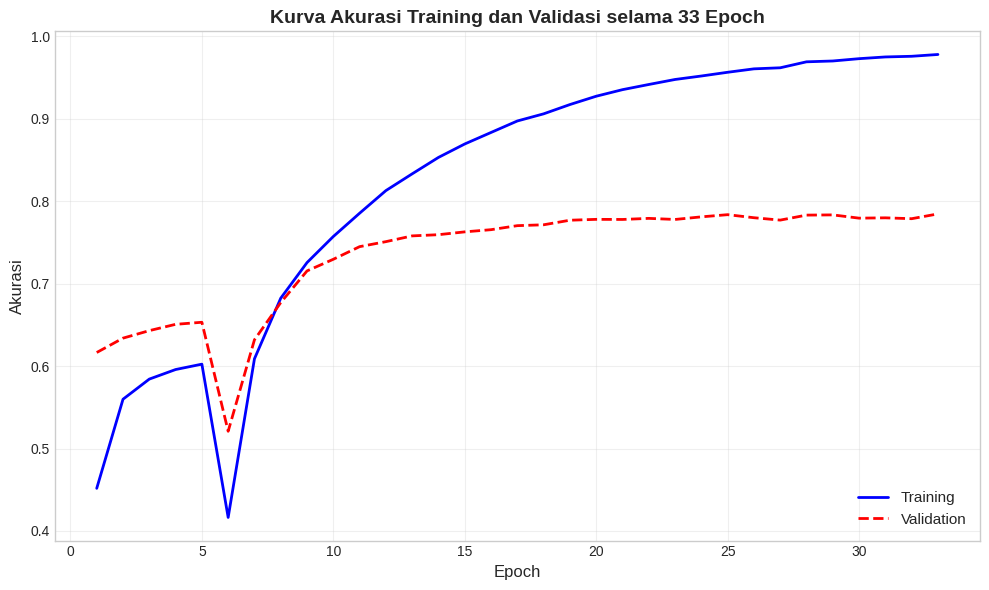

In [ ]:
# @title 7a. Grafik Kurva Akurasi Training dan Validasi (Gambar 4.1)
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Ambil data dari history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)
total_epochs = len(acc)

# Plot tunggal: Akurasi
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, acc, label='Training', color='blue', linewidth=2)
ax.plot(epochs_range, val_acc, label='Validation', color='red', linestyle='--', linewidth=2)
ax.set_title(f'Kurva Akurasi Training dan Validasi selama {total_epochs} Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


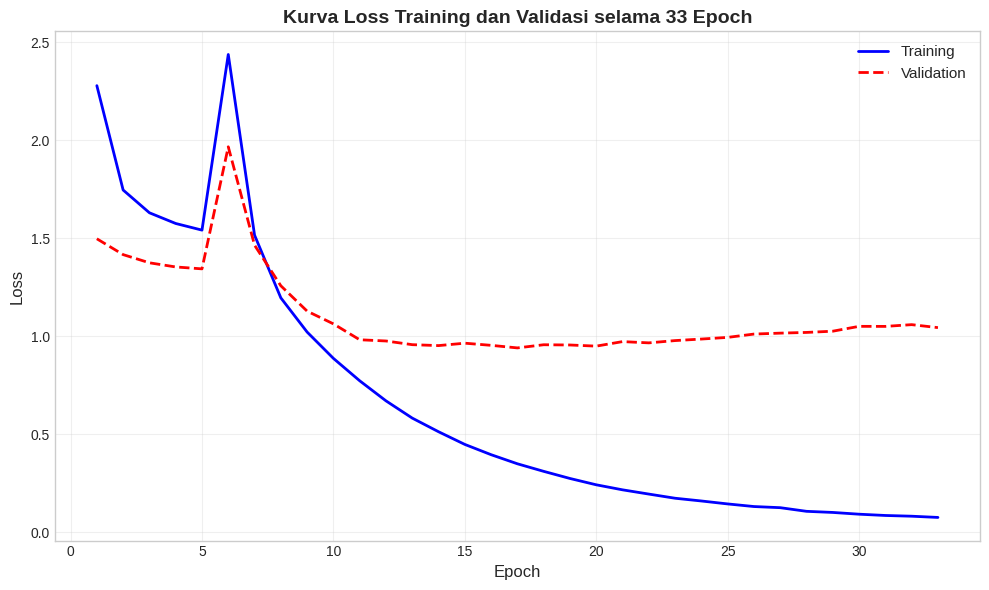

In [ ]:
# @title 7b. Grafik Kurva Loss Training dan Validasi (Gambar 4.2)
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Ambil data dari history training
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)
total_epochs = len(loss)

# Plot tunggal: Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, loss, label='Training', color='blue', linewidth=2)
ax.plot(epochs_range, val_loss, label='Validation', color='red', linestyle='--', linewidth=2)
ax.set_title(f'Kurva Loss Training dan Validasi selama {total_epochs} Epoch', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


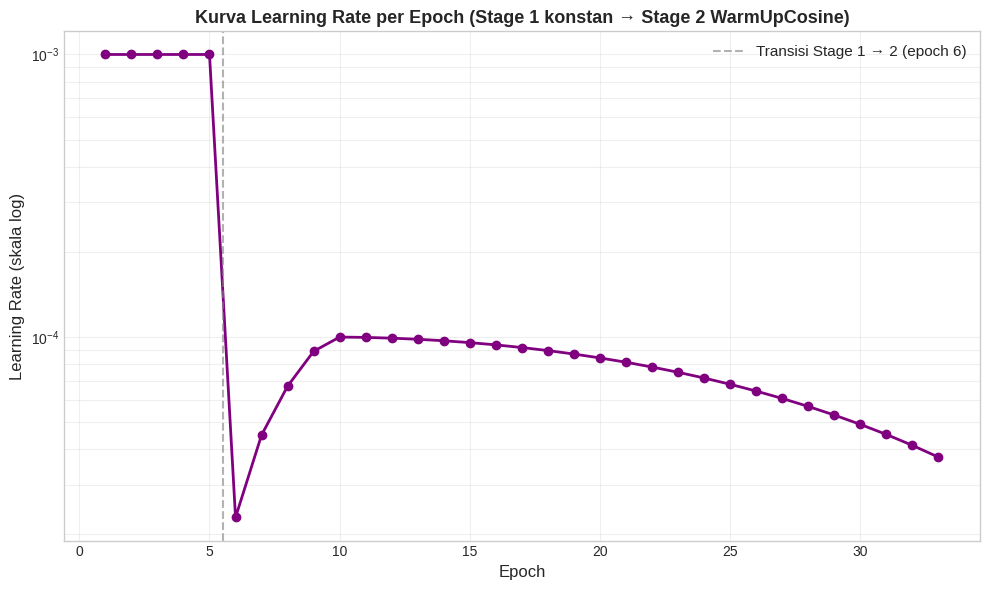

📊 Rentang LR tercatat : 2.30e-05 .. 1.00e-03


In [ ]:
# @title 7c. Grafik Learning Rate Schedule per Epoch (Gambar 4.3)
import os
import matplotlib.pyplot as plt
import pandas as pd

log_path = os.path.join(MODELS_DIR, 'training_log.csv')
df_log = pd.read_csv(log_path)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

epochs_x = df_log['epoch'].values + 1  # 1-indexed untuk pembaca
ax.plot(epochs_x, df_log['lr'].values, color='purple', linewidth=2, marker='o')
ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6,
           label=f'Transisi Stage 1 → 2 (epoch {STAGE1_EPOCHS + 1})')
ax.set_yscale('log')
ax.set_title('Kurva Learning Rate per Epoch (Stage 1 konstan → Stage 2 WarmUpCosine)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate (skala log)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Rentang LR tercatat : {df_log['lr'].min():.2e} .. {df_log['lr'].max():.2e}")


In [ ]:
# @title 8. Evaluasi Model pada Test Set (Held-out: test.txt)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import numpy as np

print("=" * 64)
print("  EVALUASI FINAL PADA TEST SET (test.txt — HELD-OUT)")
print("=" * 64)

# --- A. Evaluasi Streaming (TIDAK memuat semua gambar ke RAM) ---
print("\n🔄 Menjalankan model.evaluate pada test_ds (streaming)...")
test_metrics = model.evaluate(test_ds, verbose=1, return_dict=True)
print(f"\n📊 METRIK tf.keras:")
print(f"   Test Loss           : {test_metrics['loss']:.4f}")
print(f"   Test Accuracy       : {test_metrics['accuracy']*100:.2f}%")
print(f"   Test Top-5 Accuracy : {test_metrics['top5_acc']*100:.2f}%")

# --- B. Prediksi Streaming untuk Analisis Detail ---
print("\n🔄 Menjalankan model.predict pada test_ds (streaming)...")
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)  # test_ds tidak di-shuffle → urutan sesuai test_labels

assert len(y_pred) == len(y_true), f"Mismatch panjang: pred={len(y_pred)}, true={len(y_true)}"

# --- C. Hitung Metrik Tambahan (Precision, Recall, F1, Top-5) ---
overall_acc   = accuracy_score(y_true, y_pred)
prec_macro    = precision_score(y_true, y_pred, average='macro',    zero_division=0)
prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec_macro     = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
rec_weighted  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
f1_macro      = f1_score(y_true, y_pred,        average='macro',    zero_division=0)
f1_weighted   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

# Top-5 Accuracy manual (cross-check dengan metrik Keras)
top5_preds   = np.argsort(-y_pred_probs, axis=1)[:, :5]
top5_correct = np.any(top5_preds == y_true.reshape(-1, 1), axis=1)
top5_acc     = np.mean(top5_correct)

# --- D. Tabel Ringkas Metrik (untuk skripsi Bab IV) ---
print("\n" + "=" * 64)
print("  📋 TABEL METRIK EVALUASI PADA TEST SET FOOD-101")
print("=" * 64)
print(f"  {'Metric':<32}{'Score':>12}")
print(f"  {'-'*32}{'-'*12}")
print(f"  {'Accuracy':<32}{overall_acc*100:>11.2f}%")
print(f"  {'Top-5 Accuracy':<32}{top5_acc*100:>11.2f}%")
print(f"  {'Precision (macro)':<32}{prec_macro*100:>11.2f}%")
print(f"  {'Precision (weighted)':<32}{prec_weighted*100:>11.2f}%")
print(f"  {'Recall (macro)':<32}{rec_macro*100:>11.2f}%")
print(f"  {'Recall (weighted)':<32}{rec_weighted*100:>11.2f}%")
print(f"  {'F1-Score (macro)':<32}{f1_macro*100:>11.2f}%")
print(f"  {'F1-Score (weighted)':<32}{f1_weighted*100:>11.2f}%")
print("=" * 64)

# --- E. Classification Report Per-Kelas (untuk Lampiran skripsi) ---
print("\n📑 Classification Report (per-kelas, 4 desimal):\n")
print(classification_report(
    y_true, y_pred,
    target_names=loaded_class_names,
    digits=4,
    zero_division=0
))


  EVALUASI FINAL PADA TEST SET (test.txt — HELD-OUT)

🔄 Menjalankan model.evaluate pada test_ds (streaming)...
395/395 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.8333 - loss: 0.6731 - top5_acc: 0.9620

📊 METRIK tf.keras:
   Test Loss           : 0.6731
   Test Accuracy       : 83.33%
   Test Top-5 Accuracy : 96.20%

🔄 Menjalankan model.predict pada test_ds (streaming)...
395/395 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step

  📋 TABEL METRIK EVALUASI PADA TEST SET FOOD-101
  Metric                                 Score
  --------------------------------------------
  Accuracy                              83.33%
  Top-5 Accuracy                        96.20%
  Precision (macro)                     83.60%
  Precision (weighted)                  83.60%
  Recall (macro)                        83.33%
  Recall (weighted)                     83.33%
  F1-Score (macro)                      83.34%
  F1-Score (weighted)                   83.34%

📑 Classification Report (per-kelas, 4 desimal):

       

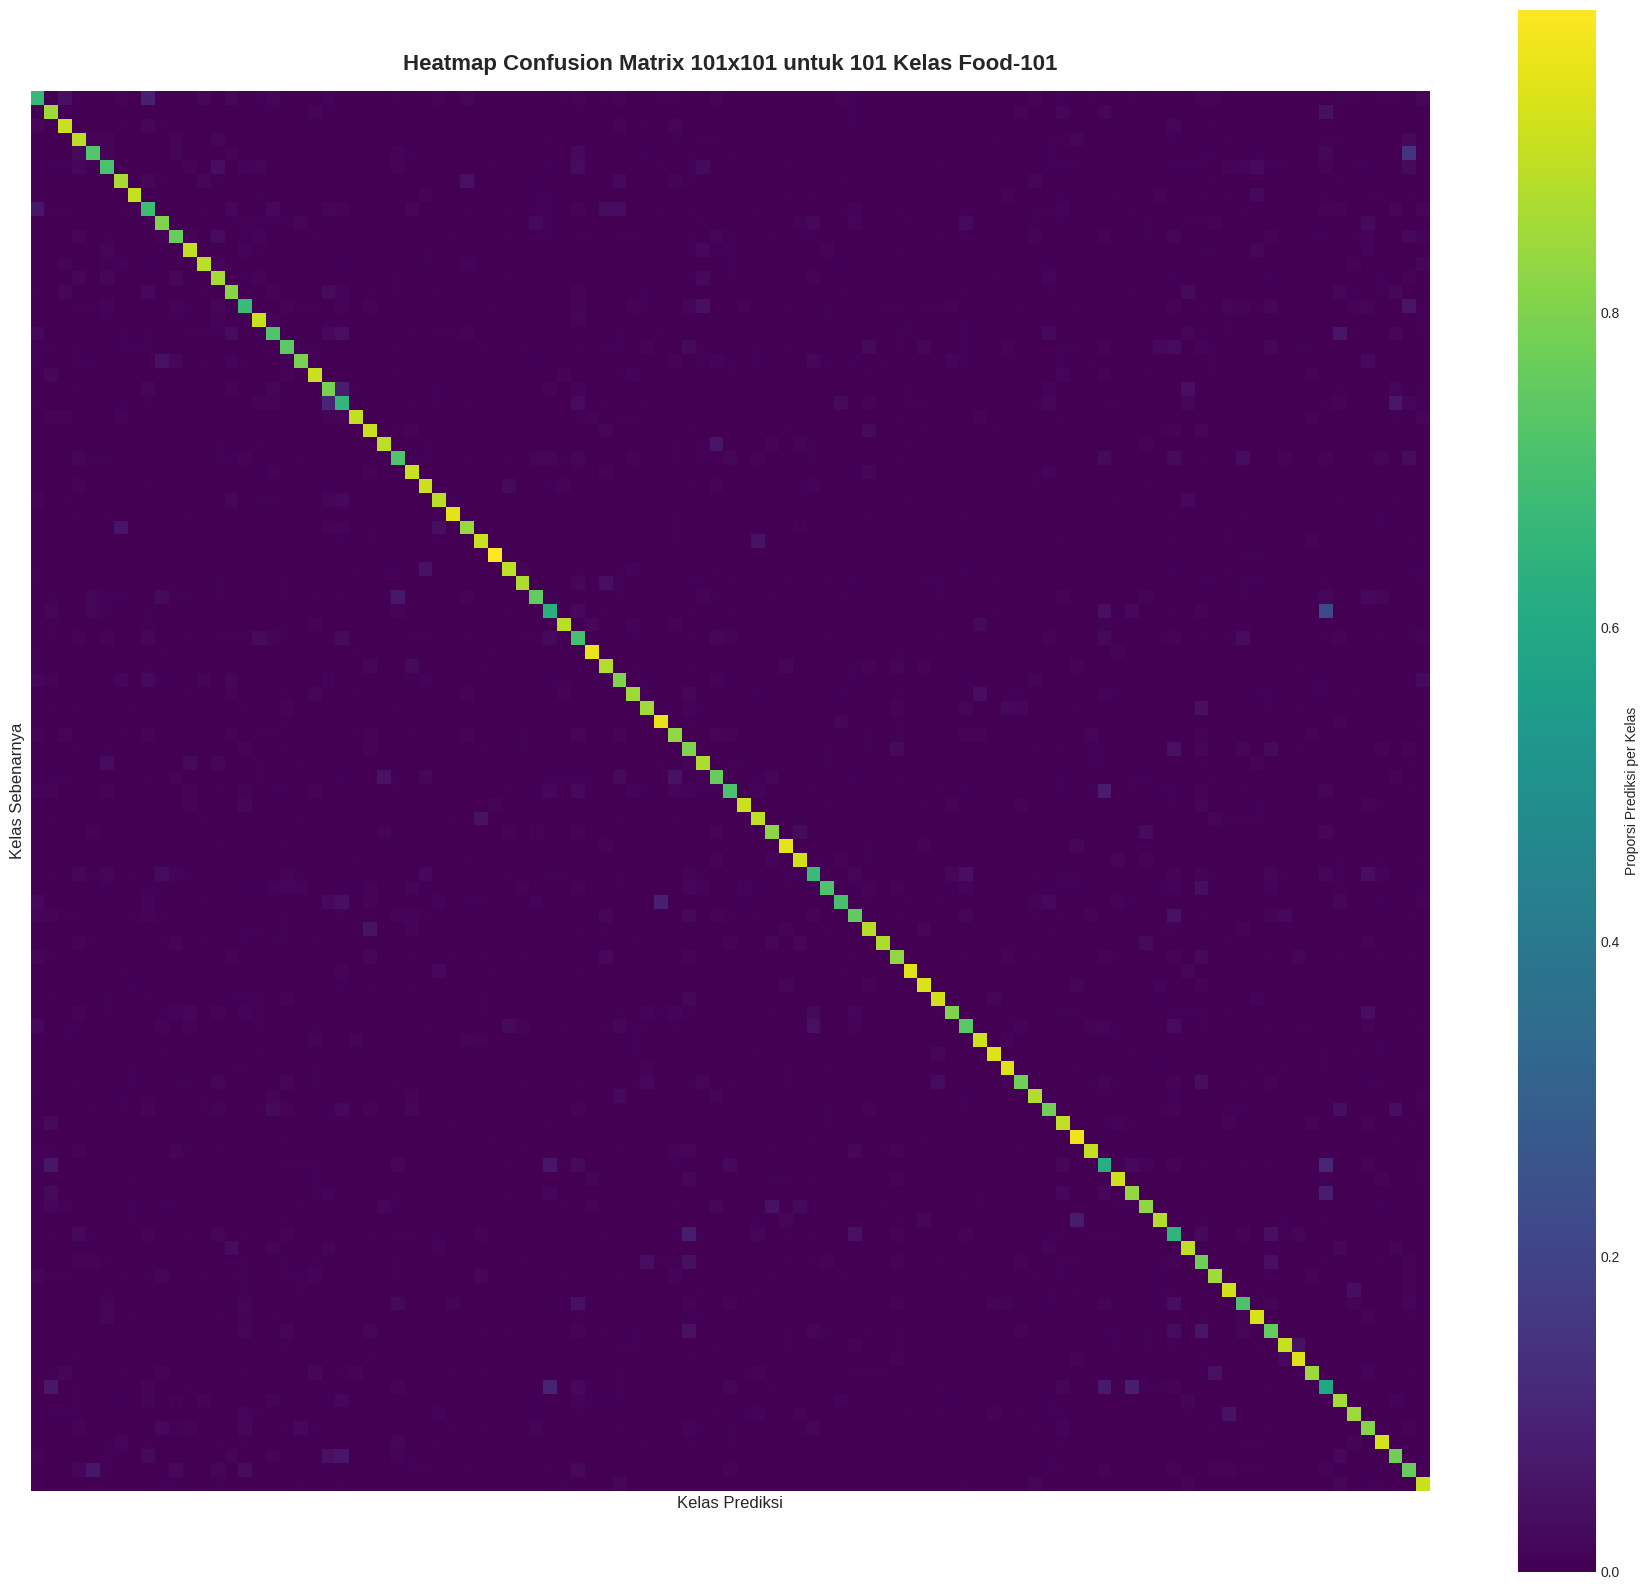


=== 10 Pasangan Kelas dengan Kesalahan Prediksi Tertinggi ===
 1. filet_mignon                   -> steak                          : 55 kesalahan
 2. beef_tartare                   -> tuna_tartare                   : 36 kesalahan
 3. pork_chop                      -> steak                          : 25 kesalahan
 4. chocolate_mousse               -> chocolate_cake                 : 25 kesalahan
 5. steak                          -> filet_mignon                   : 24 kesalahan
 6. ice_cream                      -> frozen_yogurt                  : 22 kesalahan
 7. apple_pie                      -> bread_pudding                  : 22 kesalahan
 8. steak                          -> prime_rib                      : 20 kesalahan
 9. chocolate_cake                 -> chocolate_mousse               : 20 kesalahan
10. ravioli                        -> gnocchi                        : 19 kesalahan


In [ ]:
# @title 8b. Heatmap Confusion Matrix 101x101 (Gambar 4.4)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix 101 x 101
cm = confusion_matrix(y_true, y_pred)

# Normalisasi per-baris (per kelas sebenarnya) agar skala seragam
cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

# Visualisasi heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_normalized,
    cmap='viridis',
    square=True,
    cbar_kws={'label': 'Proporsi Prediksi per Kelas'},
    xticklabels=False,
    yticklabels=False,
    ax=ax
)
ax.set_title('Heatmap Confusion Matrix 101x101 untuk 101 Kelas Food-101',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Prediksi', fontsize=12)
ax.set_ylabel('Kelas Sebenarnya', fontsize=12)

plt.tight_layout()
plt.show()

# Analisis kesalahan tertinggi (mendukung Tabel 4.3)
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
pairs = []
for i in range(cm_offdiag.shape[0]):
    for j in range(cm_offdiag.shape[1]):
        if cm_offdiag[i, j] > 0:
            pairs.append((cm_offdiag[i, j], loaded_class_names[i], loaded_class_names[j]))
pairs.sort(reverse=True)

print("\n=== 10 Pasangan Kelas dengan Kesalahan Prediksi Tertinggi ===")
for k, (cnt, true_cls, pred_cls) in enumerate(pairs[:10], 1):
    print(f"{k:2d}. {true_cls:30s} -> {pred_cls:30s} : {cnt} kesalahan")


In [ ]:
# @title 9. Akurasi Per Kelas Makanan (Tabel Lengkap)
import pandas as pd
import numpy as np

print("=" * 60)
print("  AKURASI PER KELAS MAKANAN (101 KELAS)")
print("=" * 60)

# --- A. Hitung Akurasi Tiap Kelas ---
num_classes = len(loaded_class_names)
per_class_correct = np.zeros(num_classes)
per_class_total = np.zeros(num_classes)

for i in range(len(y_true)):
    true_label = y_true[i]
    per_class_total[true_label] += 1
    if y_pred[i] == true_label:
        per_class_correct[true_label] += 1

per_class_accuracy = per_class_correct / per_class_total

# --- B. Buat DataFrame Lengkap ---
df_accuracy = pd.DataFrame({
    'No': range(1, num_classes + 1),
    'Kelas Makanan': [name.replace('_', ' ').title() for name in loaded_class_names],
    'Label Asli': loaded_class_names,
    'Jumlah Sampel': per_class_total.astype(int),
    'Prediksi Benar': per_class_correct.astype(int),
    'Prediksi Salah': (per_class_total - per_class_correct).astype(int),
    'Akurasi (%)': np.round(per_class_accuracy * 100, 2)
})
df_accuracy = df_accuracy.set_index('No')

# --- C. Urutkan berdasarkan Akurasi (Tertinggi ke Terendah) ---
df_sorted = df_accuracy.sort_values(by='Akurasi (%)', ascending=False).reset_index(drop=True)
df_sorted.index = range(1, len(df_sorted) + 1)
df_sorted.index.name = 'Rank'

# --- D. Tampilkan Tabel Lengkap ---
pd.set_option('display.max_rows', 110)
print("\n📋 TABEL AKURASI SELURUH 101 KELAS (Diurutkan Tertinggi → Terendah):\n")
display(df_sorted[['Kelas Makanan', 'Jumlah Sampel', 'Prediksi Benar', 'Prediksi Salah', 'Akurasi (%)']])

# --- E. Statistik Ringkasan ---
print("\n" + "=" * 60)
print("  RINGKASAN STATISTIK AKURASI PER KELAS")
print("=" * 60)
print(f"  Rata-rata Akurasi   : {per_class_accuracy.mean()*100:.2f}%")
print(f"  Median Akurasi      : {np.median(per_class_accuracy)*100:.2f}%")
print(f"  Std. Deviasi        : {per_class_accuracy.std()*100:.2f}%")
print(f"  Akurasi Tertinggi   : {per_class_accuracy.max()*100:.2f}% ({loaded_class_names[np.argmax(per_class_accuracy)].replace('_',' ').title()})")
print(f"  Akurasi Terendah    : {per_class_accuracy.min()*100:.2f}% ({loaded_class_names[np.argmin(per_class_accuracy)].replace('_',' ').title()})")
print(f"  Kelas >= 90%        : {np.sum(per_class_accuracy >= 0.90)} kelas")
print(f"  Kelas >= 80%        : {np.sum(per_class_accuracy >= 0.80)} kelas")
print(f"  Kelas <  60%        : {np.sum(per_class_accuracy <  0.60)} kelas")
print("=" * 60)

  AKURASI PER KELAS MAKANAN (101 KELAS)

📋 TABEL AKURASI SELURUH 101 KELAS (Diurutkan Tertinggi → Terendah):



,Kelas Makanan,Jumlah Sampel,Prediksi Benar,Prediksi Salah,Akurasi (%)
Rank,,,,,
1,Edamame,250,248,2,99.2
2,Pho,250,242,8,96.8
3,French Fries,250,240,10,96.0
4,Frozen Yogurt,250,239,11,95.6
5,Hot And Sour Soup,250,238,12,95.2
6,Deviled Eggs,250,237,13,94.8
7,Macarons,250,236,14,94.4
8,Spaghetti Carbonara,250,235,15,94.0
9,Oysters,250,235,15,94.0



  RINGKASAN STATISTIK AKURASI PER KELAS
  Rata-rata Akurasi   : 83.33%
  Median Akurasi      : 86.00%
  Std. Deviasi        : 9.22%
  Akurasi Tertinggi   : 99.20% (Edamame)
  Akurasi Terendah    : 59.20% (Steak)
  Kelas >= 90%        : 31 kelas
  Kelas >= 80%        : 69 kelas
  Kelas <  60%        : 1 kelas


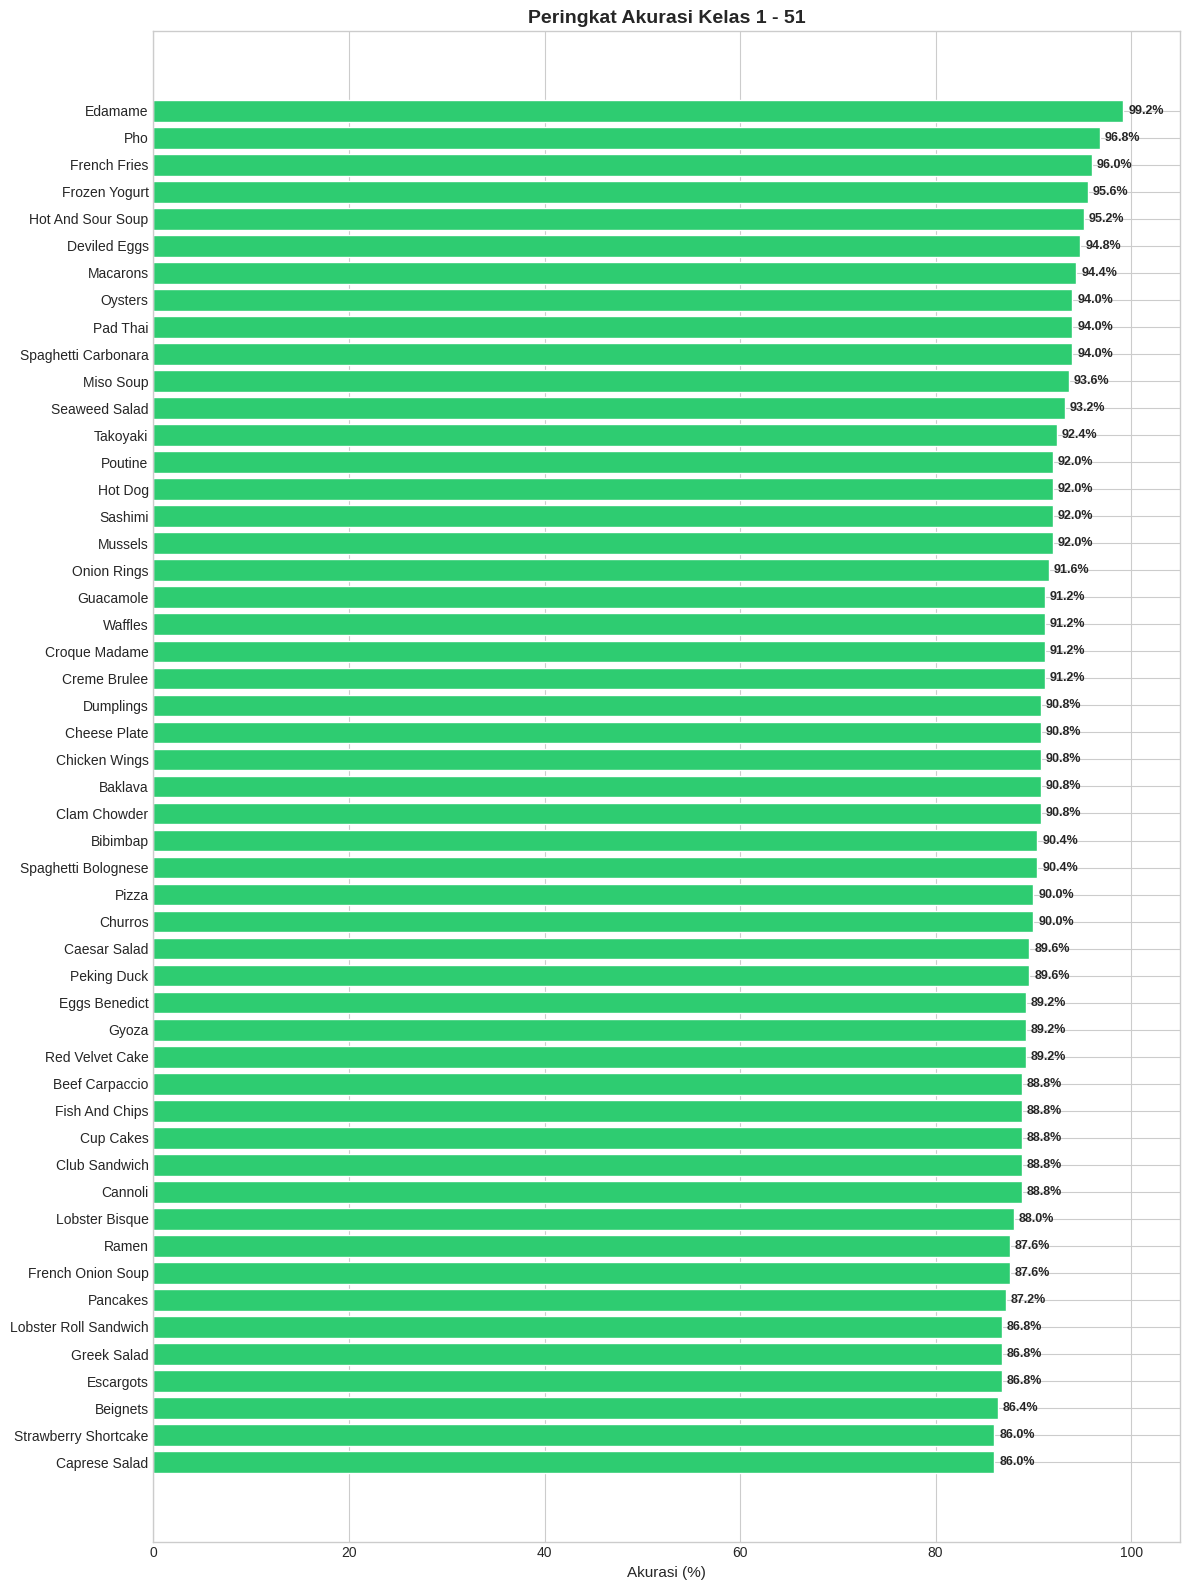

In [ ]:
# @title 10a. Visualisasi Peringkat Akurasi Kelas 1 - 51
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]

# Kolom tunggal: Peringkat 1 - 51
fig, ax = plt.subplots(figsize=(12, 16))
bars = ax.barh(range(51), all_acc[:51], color='#2ecc71', edgecolor='white')
ax.set_yticks(range(51))
ax.set_yticklabels(all_names[:51], fontsize=10)
ax.set_xlabel('Akurasi (%)', fontsize=11)
ax.set_title('Peringkat Akurasi Kelas 1 - 51', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)
ax.invert_yaxis()
for bar, val in zip(bars, all_acc[:51]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


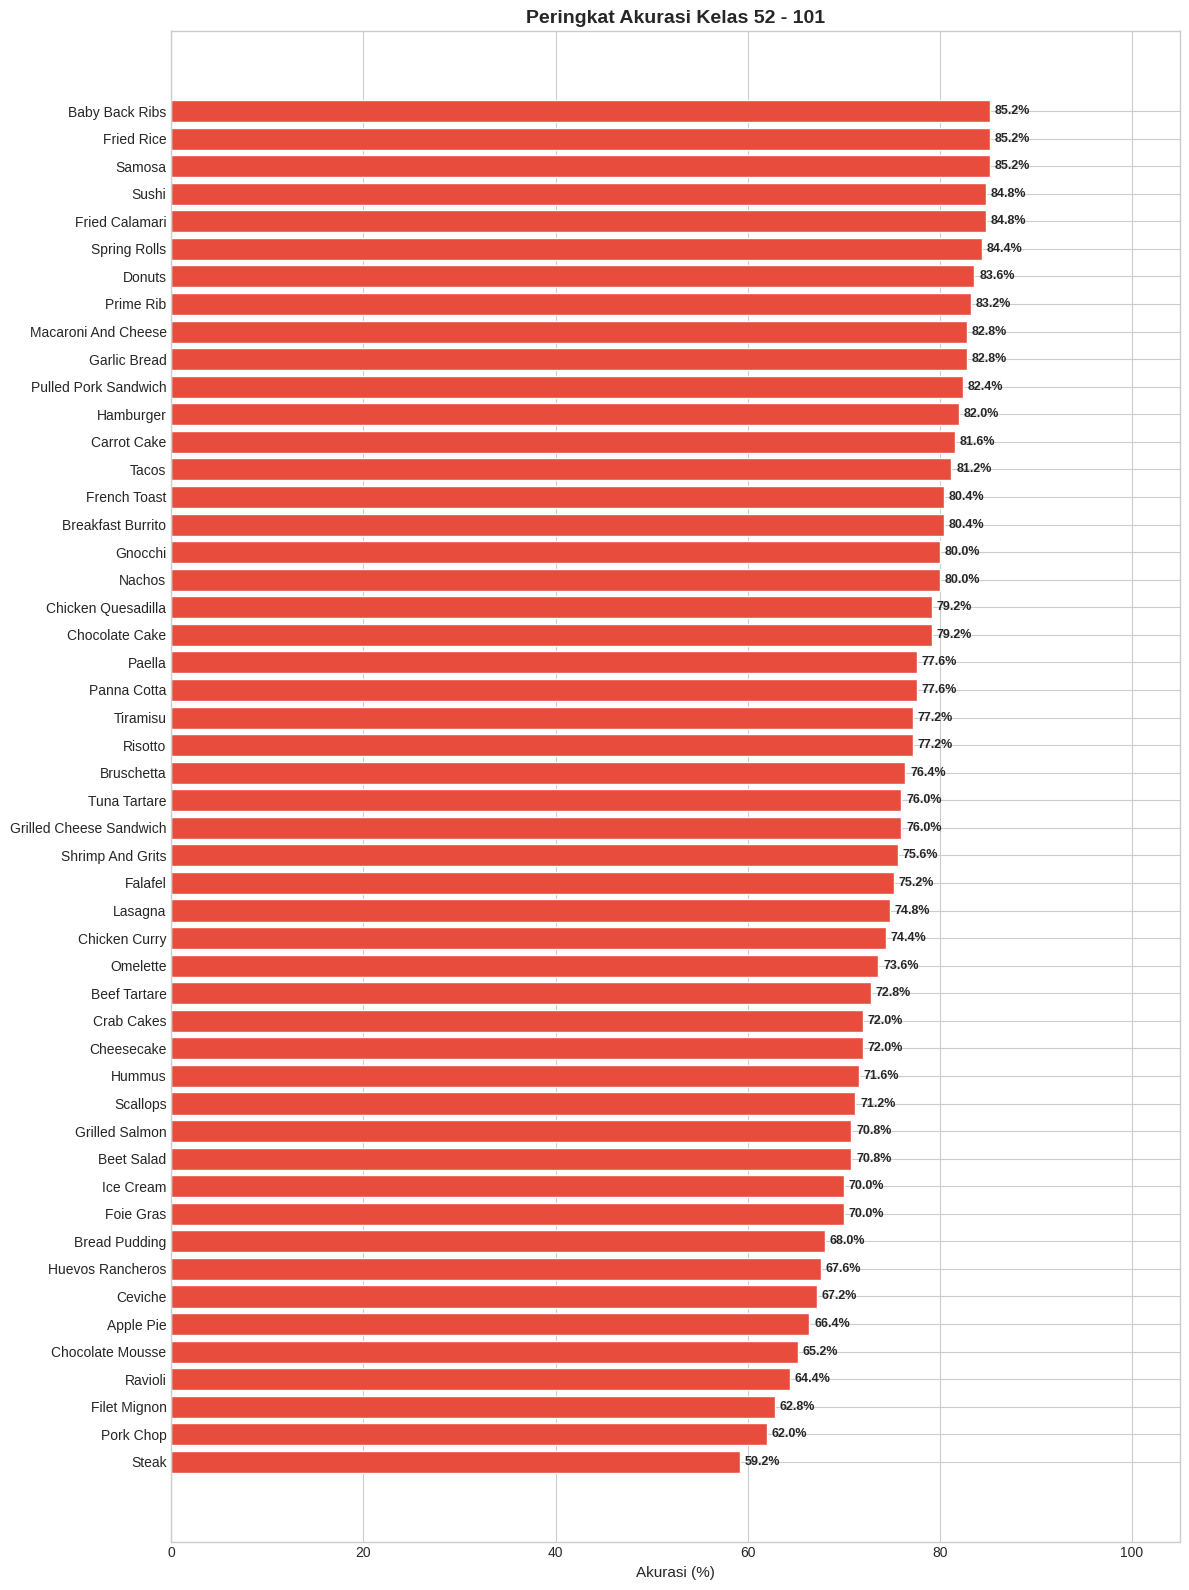

In [ ]:
# @title 10b. Visualisasi Peringkat Akurasi Kelas 52 - 101
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]

sisa_kelas = len(all_acc) - 51
if sisa_kelas > 0:
    fig, ax = plt.subplots(figsize=(12, 16))
    bars = ax.barh(range(sisa_kelas), all_acc[51:], color='#e74c3c', edgecolor='white')
    ax.set_yticks(range(sisa_kelas))
    ax.set_yticklabels(all_names[51:], fontsize=10)
    ax.set_xlabel('Akurasi (%)', fontsize=11)
    ax.set_title(f'Peringkat Akurasi Kelas 52 - {len(all_acc)}', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()
    for bar, val in zip(bars, all_acc[51:]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()


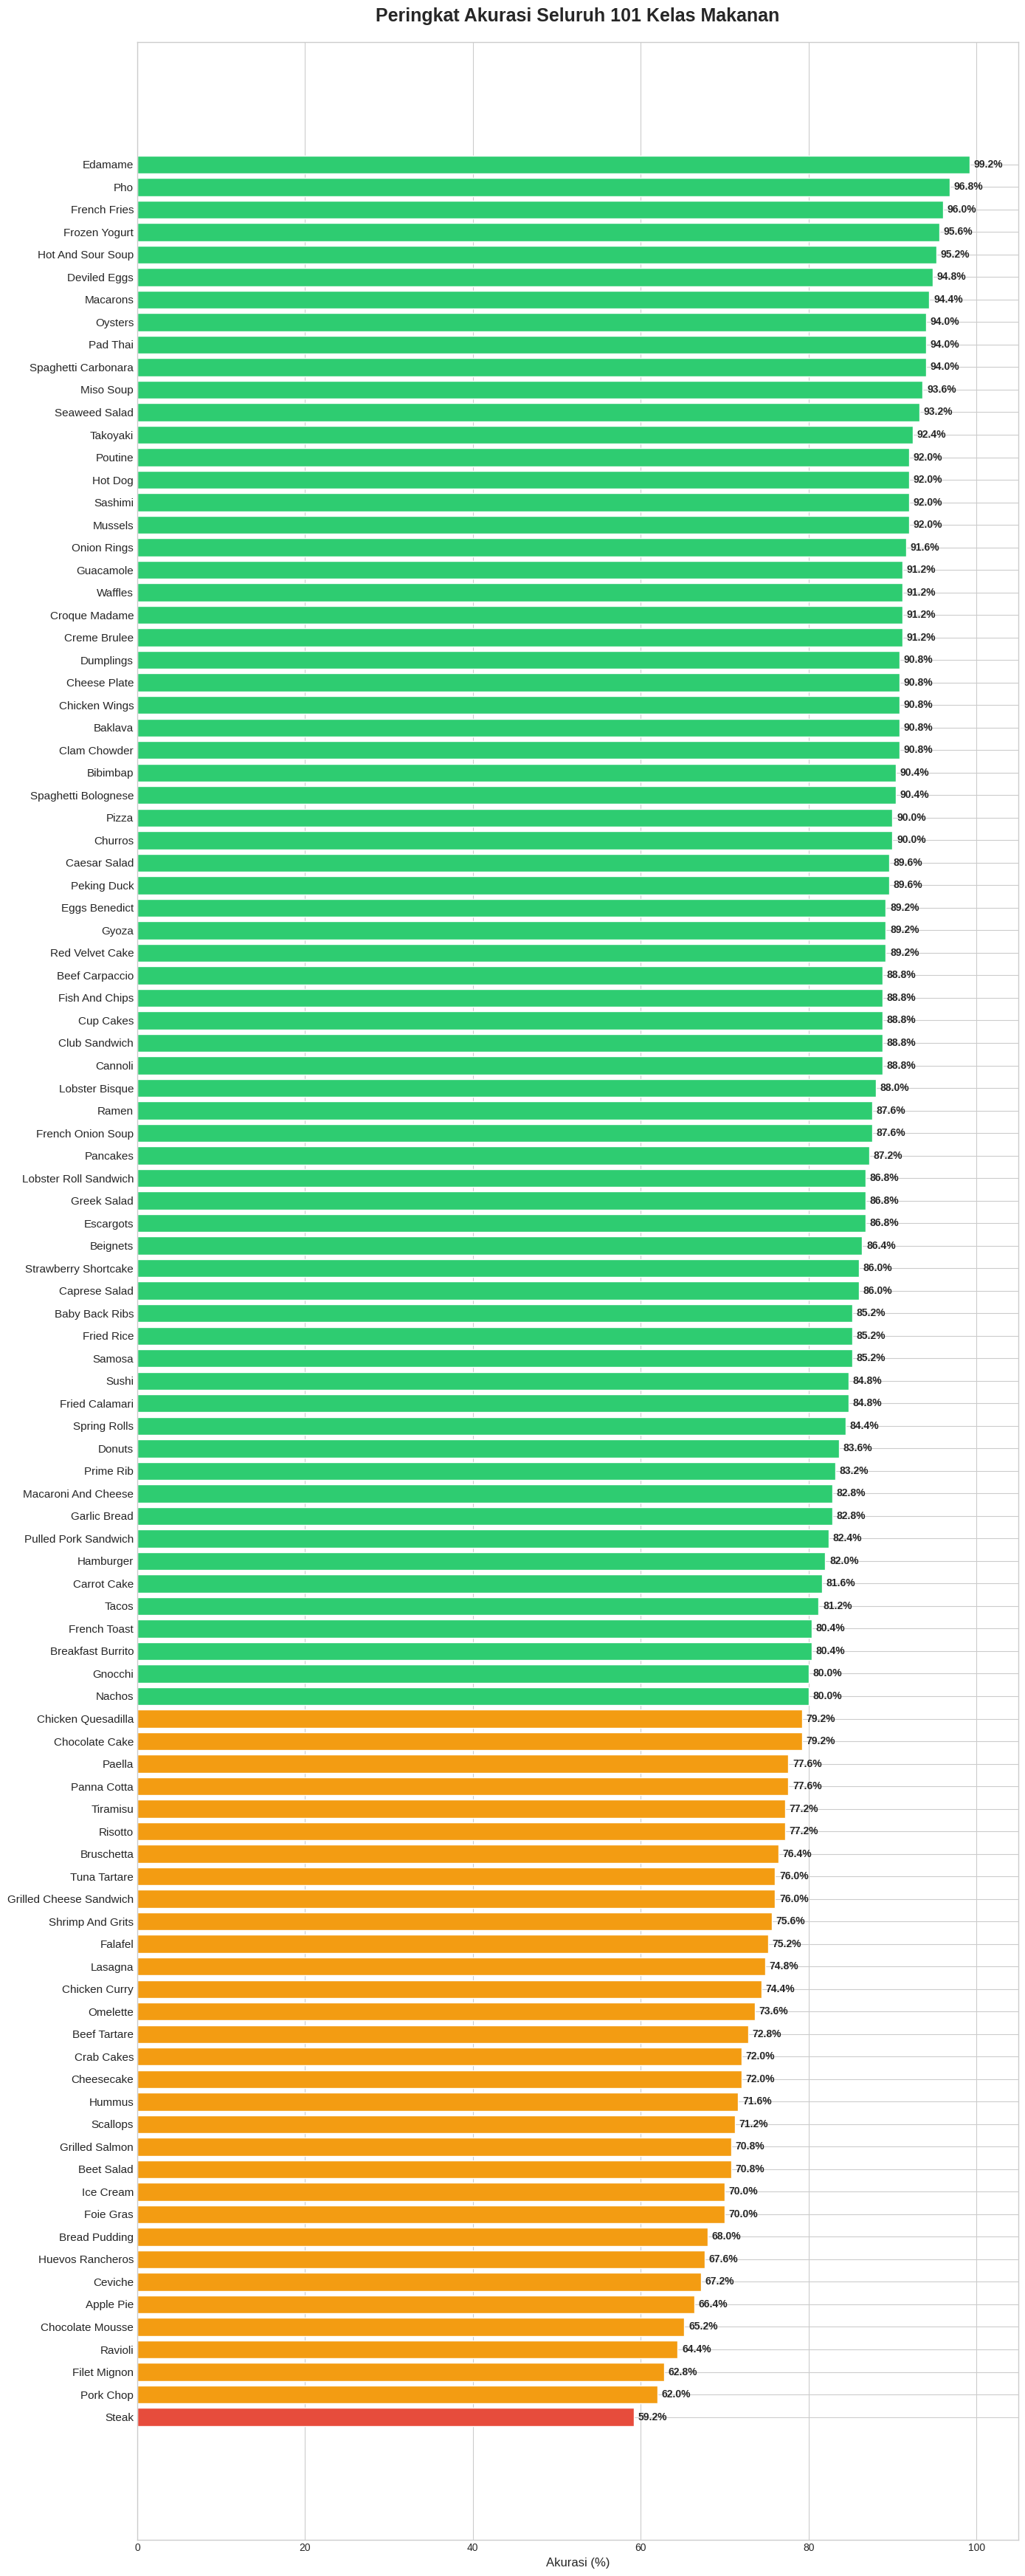

In [ ]:
# @title 11. Peringkat Akurasi Seluruh 101 Kelas
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Urutkan seluruh 101 kelas dari tertinggi ke terendah
sorted_indices_desc = np.argsort(per_class_accuracy)[::-1]

all_names = [loaded_class_names[i].replace('_', ' ').title() for i in sorted_indices_desc]
all_acc = [per_class_accuracy[i] * 100 for i in sorted_indices_desc]
total_classes = len(all_acc)

# Buat figure dengan 1 kolom dan tinggi yang sangat panjang (misal: lebar 14, tinggi 35)
fig, ax = plt.subplots(figsize=(14, 35))

# Tentukan warna (Hijau >= 80%, Oranye 60-79%, Merah < 60%)
colors = ['#2ecc71' if a >= 80 else '#f39c12' if a >= 60 else '#e74c3c' for a in all_acc]

# Buat bar chart horizontal
bars = ax.barh(range(total_classes), all_acc, color=colors, edgecolor='white')

# Set label sumbu Y dengan nama-nama kelas makanan
ax.set_yticks(range(total_classes))
ax.set_yticklabels(all_names, fontsize=11)
ax.set_xlabel('Akurasi (%)', fontsize=12)
ax.set_title(f'Peringkat Akurasi Seluruh {total_classes} Kelas Makanan', fontsize=18, fontweight='bold', pad=20)
ax.set_xlim(0, 105)

# Balik sumbu Y agar peringkat 1 berada di paling atas
ax.invert_yaxis()

# Tambahkan label teks persentase di ujung kanan setiap bar
for bar, val in zip(bars, all_acc):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

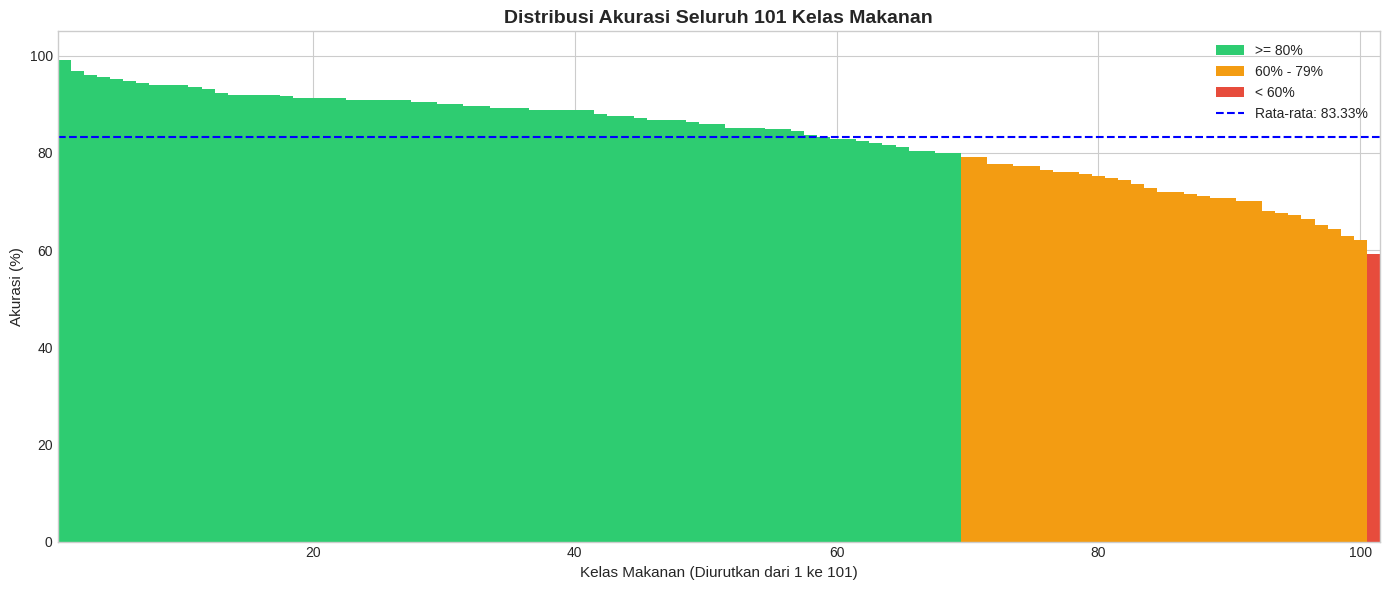

In [ ]:
# @title 12. Distribusi Akurasi Seluruh Kelas
fig, ax = plt.subplots(figsize=(14, 6))

all_acc_sorted = np.sort(per_class_accuracy * 100)[::-1]
colors = ['#2ecc71' if a >= 80 else '#f39c12' if a >= 60 else '#e74c3c' for a in all_acc_sorted]

# UBAH DI SINI: Gunakan range(1, 102) agar dimulai dari 1
ax.bar(range(1, len(all_acc_sorted) + 1), all_acc_sorted, color=colors, width=1.0, edgecolor='none')

rata_rata = np.mean(per_class_accuracy) * 100
ax.axhline(y=rata_rata, color='blue', linestyle='--', linewidth=1.5, label=f'Rata-rata: {rata_rata:.2f}%')

ax.set_xlabel('Kelas Makanan (Diurutkan dari 1 ke 101)', fontsize=11)
ax.set_ylabel('Akurasi (%)', fontsize=11)
ax.set_title(f'Distribusi Akurasi Seluruh {len(all_acc_sorted)} Kelas Makanan', fontsize=14, fontweight='bold')

# UBAH DI SINI: Geser limit sumbu X
ax.set_xlim(0.5, len(all_acc_sorted) + 0.5)
ax.set_ylim(0, 105)

# Legenda warna
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='>= 80%'),
    Patch(facecolor='#f39c12', label='60% - 79%'),
    Patch(facecolor='#e74c3c', label='< 60%')
]
ax.legend(handles=legend_elements + [ax.get_lines()[0]], loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

## 4.3 Perbandingan dengan Literatur

Tabel berikut membandingkan akurasi Top-1 model pada Food-101 dengan publikasi rujukan. Model EfficientNetV2-B0 dipilih karena ukuran parameter kecil (± 5,9 M) yang cocok untuk deployment browser via TensorFlow.js, namun tetap kompetitif dengan arsitektur state-of-the-art yang jauh lebih besar.


In [ ]:
# @title 12b. Perbandingan Akurasi dengan Literatur pada Food-101
import os
import pandas as pd

# Ambil akurasi test dari Cell 8 bila tersedia
if 'overall_acc' in globals():
    our_acc = overall_acc * 100.0
elif 'test_metrics' in globals():
    our_acc = test_metrics['accuracy'] * 100.0
else:
    our_acc = float('nan')

comparison = pd.DataFrame([
    {'Penelitian': 'Bossard et al. (2014) — RFDC',            'Arsitektur': 'Random Forest',     'Top-1 Acc (%)': 50.76},
    {'Penelitian': 'Liu et al. (2016) — DeepFood',            'Arsitektur': 'Inception v3',      'Top-1 Acc (%)': 77.40},
    {'Penelitian': 'Hassannejad et al. (2016)',               'Arsitektur': 'Inception v3',      'Top-1 Acc (%)': 88.28},
    {'Penelitian': 'Martinel et al. (2018) — WISeR',          'Arsitektur': 'Wide-Slice Residual', 'Top-1 Acc (%)': 90.27},
    {'Penelitian': 'Tan & Le (2021)',                          'Arsitektur': 'EfficientNetV2-L',  'Top-1 Acc (%)': 91.70},
    {'Penelitian': 'Penelitian Ini (Skripsi)',                'Arsitektur': 'EfficientNetV2-B0', 'Top-1 Acc (%)': round(our_acc, 2)},
])

comparison_sorted = comparison.sort_values('Top-1 Acc (%)', ascending=True).reset_index(drop=True)

print("=" * 90)
print("  TABEL PERBANDINGAN AKURASI Top-1 pada Food-101 (dari terendah ke tertinggi)")
print("=" * 90)
try:
    from IPython.display import display
    display(comparison_sorted)
except Exception:
    print(comparison_sorted.to_string(index=False))

out_path = os.path.join(MODELS_DIR, 'literature_comparison.csv')
comparison_sorted.to_csv(out_path, index=False)
print(f"\n💾 Tabel disimpan ke: {out_path}")


  TABEL PERBANDINGAN AKURASI Top-1 pada Food-101 (dari terendah ke tertinggi)


,Penelitian,Arsitektur,Top-1 Acc (%)
0,Bossard et al. (2014) — RFDC,Random Forest,50.76
1,Liu et al. (2016) — DeepFood,Inception v3,77.40
2,Penelitian Ini (Skripsi),EfficientNetV2-B0,83.33
3,Hassannejad et al. (2016),Inception v3,88.28
4,Martinel et al. (2018) — WISeR,Wide-Slice Residual,90.27
5,Tan & Le (2021),EfficientNetV2-L,91.70



💾 Tabel disimpan ke: /content/drive/MyDrive/Skripsi/Deep_Learning/models/literature_comparison.csv


## 4.4 Deployment — Konversi Final ke TensorFlow.js

Model hasil training dikonversi ke format TensorFlow.js dengan **quantisasi float16** agar ukuran file rendah (cocok untuk di-*serve* langsung dari web). Karena API Keras 3 tidak lagi kompatibel penuh dengan `tensorflowjs_converter`, dilakukan *weight transplant*: bobot dari model Keras 3 disalin layer-per-layer ke arsitektur ekuivalen di `tf_keras` (Keras 2 legacy), lalu disimpan sebagai SavedModel dan dikonversi.


In [ ]:
# @title 13. Konversi Final ke TensorFlow.js (EfficientNet Transplant + File Check)
import os
import shutil
import json
import tensorflow as tf
import keras # Keras 3
from zipfile import ZipFile

# --- 1. SETUP ---
print("📦 Menginstall library konverter...")
os.system('pip install -q tensorflowjs tf_keras')
import tf_keras # Keras 2 Legacy

if not os.path.exists(MODELS_DIR): os.makedirs(MODELS_DIR)
saved_model_path = os.path.join(MODELS_DIR, 'legacy_saved_model_folder')
OUTPUT_PACKAGE_DIR = os.path.join(MODELS_DIR, 'tfjs_output_folder')
ZIP_PATH = os.path.join(MODELS_DIR, 'model_website_siap_pakai.zip')

# --- 2. DEFINISI WADAH LEGACY (EFFICIENTNET) ---
def build_legacy_model(num_classes):
    print("🏗️ Membangun Arsitektur Legacy (EfficientNetV2B0)...")
    inputs = tf_keras.Input(shape=(224, 224, 3))

    # Arsitektur harus SAMA PERSIS dengan Cell 4
    base_model = tf_keras.applications.EfficientNetV2B0(
        include_top=False,
        input_tensor=inputs,
        weights=None # Bobot akan dicopy manual
    )

    x = base_model.output
    x = tf_keras.layers.GlobalAveragePooling2D()(x)
    x = tf_keras.layers.BatchNormalization()(x)
    x = tf_keras.layers.Dropout(0.2)(x)
    outputs = tf_keras.layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return tf_keras.Model(inputs, outputs)

# --- 3. EKSEKUSI TRANSPLANTASI ---
if 'loaded_class_names' in globals() and 'model' in globals():
    try:
        # A. Buat Wadah
        legacy_model = build_legacy_model(len(loaded_class_names))

        # B. Salin Otak (Weights)
        print("⚖️ Menyalin bobot model Keras 3 ke Keras 2...")
        legacy_model.set_weights(model.get_weights())

        # C. Simpan Legacy
        if os.path.exists(saved_model_path): shutil.rmtree(saved_model_path)
        legacy_model.save(saved_model_path, save_format='tf')
        print(f"📁 Model Legacy tersimpan di: {saved_model_path}")

        # D. Convert
        print("🚀 Mengonversi ke TensorFlow.js...")
        if os.path.exists(OUTPUT_PACKAGE_DIR): shutil.rmtree(OUTPUT_PACKAGE_DIR)
        os.makedirs(OUTPUT_PACKAGE_DIR)

        # Classes JSON
        with open(os.path.join(OUTPUT_PACKAGE_DIR, 'classes.json'), 'w') as f:
            json.dump(loaded_class_names, f)

        # Command
        cmd = f"""tensorflowjs_converter \
            --input_format=tf_saved_model \
            --output_format=tfjs_graph_model \
            --weight_shard_size_bytes=4000000 \
            --quantize_float16=* \
            --skip_op_check \
            --strip_debug_ops=True \
            "{saved_model_path}" \
            "{OUTPUT_PACKAGE_DIR}"
        """

        if os.system(cmd) == 0:
            print("✅ KONVERSI SUKSES!")

            # --- CEK FILE (YANG ANDA MINTA) ---
            print("\n📋 DAFTAR FILE YANG DIHASILKAN:")
            files_found = os.listdir(OUTPUT_PACKAGE_DIR)
            for f in files_found:
                print(f"   📄 {f}")

            # E. Zipping
            print("\n📦 Membungkus file ZIP...")
            with ZipFile(ZIP_PATH, 'w') as zipf:
                for root, dirs, files in os.walk(OUTPUT_PACKAGE_DIR):
                    for file in files:
                        zipf.write(os.path.join(root, file), file)

                nutri_path = os.path.join(MODELS_DIR, 'nutrition.json')
                if os.path.exists(nutri_path):
                    zipf.write(nutri_path, 'nutrition.json')
                    print("   ➕ nutrition.json ditambahkan.")

            print(f"\n🎉 SELESAI! Download file ini untuk Website: {ZIP_PATH}")
        else:
            print("❌ Konversi Gagal.")

    except Exception as e:
        print(f"❌ Error: {e}")
else:
    print("⚠️ Harap jalankan training dulu (Cell 6).")

📦 Menginstall library konverter...
🏗️ Membangun Arsitektur Legacy (EfficientNetV2B0)...
⚖️ Menyalin bobot model Keras 3 ke Keras 2...


📁 Model Legacy tersimpan di: /content/drive/MyDrive/Skripsi/Deep_Learning/models/legacy_saved_model_folder
🚀 Mengonversi ke TensorFlow.js...
✅ KONVERSI SUKSES!

📋 DAFTAR FILE YANG DIHASILKAN:
   📄 classes.json
   📄 group1-shard1of3.bin
   📄 group1-shard2of3.bin
   📄 group1-shard3of3.bin
   📄 model.json

📦 Membungkus file ZIP...

🎉 SELESAI! Download file ini untuk Website: /content/drive/MyDrive/Skripsi/Deep_Learning/models/model_website_siap_pakai.zip


## 4.5 Benchmark Inferensi & Ukuran File Deployment

Dua metrik operasional penting untuk model web client-side: **ukuran file** (menentukan waktu unduh awal) dan **latensi inferensi** (menentukan UX real-time).


In [ ]:
# @title 13b. Benchmark Ukuran File TFJS + Latensi Inferensi
import os
import time
import numpy as np
import tensorflow as tf

print("=" * 64)
print("  BENCHMARK DEPLOYMENT: UKURAN FILE + LATENSI INFERENSI")
print("=" * 64)

# --- A. Ukuran file TFJS output ---
if os.path.exists(OUTPUT_PACKAGE_DIR):
    total_size_bytes = 0
    file_info = []
    for root, _, files_in_dir in os.walk(OUTPUT_PACKAGE_DIR):
        for f in files_in_dir:
            fp = os.path.join(root, f)
            size = os.path.getsize(fp)
            total_size_bytes += size
            file_info.append((f, size))

    print("\n📦 ISI FOLDER TFJS (model_website_siap_pakai):")
    for name, size in sorted(file_info):
        print(f"   {name:<40}  {size/1024:>10.1f} KB")
    print(f"   {'─ TOTAL ─':<40}  {total_size_bytes/1024/1024:>10.2f} MB")
else:
    print("⚠️  Folder TFJS belum ada — jalankan Cell 13 terlebih dahulu.")

# --- B. Benchmark latensi inferensi pada model Keras (batch=1) ---
print("\n⏱️  LATENSI INFERENSI (Keras model @ GPU Colab, batch=1):")
dummy = np.random.rand(1, 224, 224, 3).astype(np.float32)

# Warm-up (10 iterasi, hindari bias dari kompilasi graph pertama)
for _ in range(10):
    _ = model.predict(dummy, verbose=0)

# Pengukuran 100 iterasi
N = 100
t0 = time.perf_counter()
for _ in range(N):
    _ = model.predict(dummy, verbose=0)
elapsed = time.perf_counter() - t0

ms_per_inf = (elapsed / N) * 1000.0
fps = 1000.0 / ms_per_inf

print(f"   Rata-rata latensi    : {ms_per_inf:.2f} ms / gambar  (N={N})")
print(f"   Throughput estimasi  : {fps:.1f} FPS")
print("   Catatan: pengukuran di GPU Colab. Di browser TFJS dengan WebGL backend")
print("   biasanya 2–5× lebih lambat, namun dengan quantisasi float16 ukuran model")
print("   tetap ringan sehingga cocok untuk inferensi real-time client-side.")


  BENCHMARK DEPLOYMENT: UKURAN FILE + LATENSI INFERENSI

📦 ISI FOLDER TFJS (model_website_siap_pakai):
   classes.json                                     1.5 KB
   group1-shard1of3.bin                          3906.2 KB
   group1-shard2of3.bin                          3906.2 KB
   group1-shard3of3.bin                          3829.3 KB
   model.json                                     281.5 KB
   ─ TOTAL ─                                      11.65 MB

⏱️  LATENSI INFERENSI (Keras model @ GPU Colab, batch=1):
   Rata-rata latensi    : 197.58 ms / gambar  (N=100)
   Throughput estimasi  : 5.1 FPS
   Catatan: pengukuran di GPU Colab. Di browser TFJS dengan WebGL backend
   biasanya 2–5× lebih lambat, namun dengan quantisasi float16 ukuran model
   tetap ringan sehingga cocok untuk inferensi real-time client-side.


In [ ]:
# @title 14. Konversi CSV Nutrisi Food-101 (normalisasi label + fallback bertingkat) ke JSON
# Sumber dataset nutrisi: Kaggle "Food-101 Nutritional Information"
# URL: https://www.kaggle.com/datasets/sanadalali/food-101-nutritional-information
#
# Dataset Kaggle sering memakai nama SINGKAT yang sedikit berbeda dari Food-101,
# contoh: 'Lobster Roll' di CSV = 'lobster_roll_sandwich' di classes.txt,
#         'Grilled Cheese' di CSV = 'grilled_cheese_sandwich' di classes.txt.
# Cell ini menyamakan semua nama CSV ke bentuk kanonik Food-101 lewat 4 lapis matching.
#
# Strategi pencocokan label (4 lapis, dari ketat -> longgar):
#   (a) CANON-EXACT   : lowercase + strip aksen + non-alnum->'_' (exact match)
#   (b) COLLAPSED     : abaikan semua underscore  -> 'cup_cakes' = 'Cupcakes'
#   (c) TOKEN-PREFIX  : salah satu adalah token-prefix/suffix yang lain
#                       mis. 'lobster_roll' word-prefix dari 'lobster_roll_sandwich'
#   (d) FUZZY (>=0.75): difflib.get_close_matches last-resort
#
# Strategi fallback takaran (agar 101 kelas semuanya terisi):
#   1) PRIORITAS : weight == 100 gram (dipakai langsung, tanpa scaling)
#   2) FALLBACK 1: weight == 150 gram -> dinormalisasi ke per-100g (nilai x 100/150)
#   3) FALLBACK 2: takaran terkecil yang tersedia -> dinormalisasi ke per-100g
import json
import re
import unicodedata
from difflib import get_close_matches

# Path
CSV_PATH = os.path.join(MODELS_DIR, 'nutrition.csv')
JSON_PATH = os.path.join(MODELS_DIR, 'nutrition.json')
CLASSES_PATH = os.path.join(META_DIR, 'classes.txt')

# ---- Helper: normalisasi label ----
def canon(s):
    """lowercase + strip aksen + non-alnum -> '_' + squeeze '__' -> '_' + trim."""
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode('ascii')
    s = s.lower().strip()
    s = re.sub(r'[^a-z0-9]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def collapse(s):
    return canon(s).replace('_', '')

def is_token_prefix_or_suffix(a, b):
    """True jika `a` adalah word-prefix/suffix dari `b` (atau sebaliknya), syarat >=2 token.
    Contoh: a='lobster_roll', b='lobster_roll_sandwich' -> True.
    Contoh: a='chocolate', b='chocolate_cake' -> False (a hanya 1 token, terlalu generik)."""
    if a == b:
        return True
    a_toks, b_toks = a.split('_'), b.split('_')
    shorter = a if len(a_toks) <= len(b_toks) else b
    longer  = b if len(a_toks) <= len(b_toks) else a
    short_toks = shorter.split('_')
    # Syarat safety: sisi pendek minimal 2 token supaya tidak too-generic
    if len(short_toks) < 2:
        return False
    return (longer.startswith(shorter + '_')
            or longer.endswith('_' + shorter))

def sync_data():
    print('🔄 Sinkronisasi Nutrisi Food-101 (normalisasi 4-lapis + fallback 100g->150g->terkecil)')

    # 1. Load 101 kelas resmi Food-101
    if os.path.exists(CLASSES_PATH):
        with open(CLASSES_PATH, 'r') as f:
            valid_classes = [line.strip() for line in f.readlines() if line.strip()]
    else:
        valid_classes = loaded_class_names if 'loaded_class_names' in globals() else []
    if len(valid_classes) != 101:
        print(f'⚠️ Jumlah kelas tidak sama dengan 101 (ditemukan {len(valid_classes)}).')

    # 2. Load CSV nutrisi
    if not os.path.exists(CSV_PATH):
        print(f'⚠️ {CSV_PATH} tidak ditemukan. JSON tidak dibuat.')
        return {}

    try:
        df = pd.read_csv(CSV_PATH)
        df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
        df = df.dropna(subset=['weight']).copy()
        df['weight'] = df['weight'].astype(int)

        df['label_canon']    = df['label'].apply(canon)
        df['label_collapse'] = df['label'].apply(collapse)

        print(f'📊 Total baris CSV (weight valid): {len(df)}')
        print(f"   Distribusi takaran unik          : {sorted(df['weight'].unique().tolist())}")
        print(f"   Jumlah label unik (setelah canon): {df['label_canon'].nunique()}")

        unique_canon     = df['label_canon'].unique().tolist()
        unique_collapsed = df['label_collapse'].unique().tolist()

        # 3. Bangun nutrition_db
        nutrition_db = {}
        sumber_stats = {}
        no_data_classes = []
        match_mode_log = {'canon': 0, 'collapse': 0, 'token': 0, 'fuzzy': 0}
        alias_pairs = []  # (food101_class, csv_name, mode)

        for cls in valid_classes:
            cls_canon    = canon(cls)
            cls_collapse = collapse(cls)

            # --- (a) canon exact ---
            rows = df[df['label_canon'] == cls_canon]
            mode = 'canon'

            # --- (b) collapsed exact ---
            if rows.empty:
                rows = df[df['label_collapse'] == cls_collapse]
                mode = 'collapse'

            # --- (c) token-prefix/suffix (Lobster Roll <-> lobster_roll_sandwich) ---
            if rows.empty:
                cand_labels = [lbl for lbl in unique_canon if is_token_prefix_or_suffix(cls_canon, lbl)]
                if cand_labels:
                    # Ambil label CSV yang paling MIRIP (panjang token paling dekat)
                    cand_labels.sort(key=lambda x: abs(len(x.split('_')) - len(cls_canon.split('_'))))
                    chosen_label = cand_labels[0]
                    rows = df[df['label_canon'] == chosen_label]
                    mode = 'token'
                    alias_pairs.append((cls, rows.iloc[0]['label'], 'token'))

            # --- (d) fuzzy 0.75 ---
            if rows.empty:
                candidates = get_close_matches(cls_collapse, unique_collapsed, n=1, cutoff=0.75)
                if candidates:
                    rows = df[df['label_collapse'] == candidates[0]]
                    mode = 'fuzzy'
                    alias_pairs.append((cls, rows.iloc[0]['label'], 'fuzzy'))

            if rows.empty:
                nutrition_db[cls] = {
                    'kalori': '-', 'protein': '-', 'lemak': '-',
                    'karbohidrat': '-', 'takaran': '100g', 'sumber_takaran': '-'
                }
                no_data_classes.append(cls)
                continue

            # Pilih weight: 100 -> 150 -> terkecil yang tersedia
            available = sorted(rows['weight'].unique().tolist())
            if 100 in available:
                chosen_w = 100
            elif 150 in available:
                chosen_w = 150
            else:
                chosen_w = int(min(available))

            row = rows[rows['weight'] == chosen_w].iloc[0]
            scale = 100.0 / float(chosen_w)

            nutrition_db[cls] = {
                'kalori'        : str(round(float(row['calories'])      * scale, 2)),
                'protein'       : str(round(float(row['protein'])       * scale, 2)),
                'lemak'         : str(round(float(row['fats'])          * scale, 2)),
                'karbohidrat'   : str(round(float(row['carbohydrates']) * scale, 2)),
                'takaran'       : '100g',
                'sumber_takaran': f'{chosen_w}g'
            }
            sumber_stats[chosen_w] = sumber_stats.get(chosen_w, 0) + 1
            match_mode_log[mode] = match_mode_log[mode] + 1

        # 4. Simpan JSON
        with open(JSON_PATH, 'w') as f:
            json.dump(nutrition_db, f, indent=2)

        # 5. Laporan ringkas
        matched_total = sum(match_mode_log.values())
        print(f'\n✅ SUKSES! JSON berisi {len(nutrition_db)} kelas (target: 101).')
        print(f'   Teknik matching label:')
        print(f'     • canon-exact    : {match_mode_log["canon"]:>3} kelas')
        print(f'     • collapsed      : {match_mode_log["collapse"]:>3} kelas  (underscore diabaikan)')
        print(f'     • token-prefix   : {match_mode_log["token"]:>3} kelas  (mis. "Lobster Roll" -> lobster_roll_sandwich)')
        print(f'     • fuzzy (>=75%)  : {match_mode_log["fuzzy"]:>3} kelas  (difflib)')
        print(f'     • TOTAL matched  : {matched_total:>3}/101')
        print(f'   Rincian sumber takaran (sebelum normalisasi ke 100g):')
        for w in sorted(sumber_stats.keys()):
            n = sumber_stats[w]
            tag = ' (langsung)' if w == 100 else f' (di-scale x {100.0/w:.4f})'
            print(f'     • {w:>4}g : {n:>3} kelas{tag}')
        if alias_pairs:
            print(f'   🔍 Pasangan alias matched (Food-101 ← CSV):')
            for cls_name, csv_name, m in alias_pairs[:15]:
                print(f'     [{m:<6}] {cls_name:<30} ← {csv_name}')
            if len(alias_pairs) > 15:
                print(f'     ... dan {len(alias_pairs) - 15} alias lainnya')
        if no_data_classes:
            suffix = '...' if len(no_data_classes) > 5 else ''
            print(f'   ⚠️  {len(no_data_classes)} kelas TIDAK ADA di CSV: {no_data_classes[:5]}{suffix}')
        print(f'📂 File tersimpan: {JSON_PATH}')
        return nutrition_db

    except Exception as e:
        print(f'❌ Error CSV: {e}')
        return {}

# Variabel global 'nutrition_db' dibuat disini
nutrition_db = sync_data()

🔄 Sinkronisasi Nutrisi Food-101 (normalisasi 4-lapis + fallback 100g->150g->terkecil)
📊 Total baris CSV (weight valid): 505
   Distribusi takaran unik          : [50, 70, 80, 100, 120, 150, 200, 250, 300, 350, 400, 450, 500, 600, 700]
   Jumlah label unik (setelah canon): 101

✅ SUKSES! JSON berisi 101 kelas (target: 101).
   Teknik matching label:
     • canon-exact    :  98 kelas
     • collapsed      :   1 kelas  (underscore diabaikan)
     • token-prefix   :   2 kelas  (mis. "Lobster Roll" -> lobster_roll_sandwich)
     • fuzzy (>=75%)  :   0 kelas  (difflib)
     • TOTAL matched  : 101/101
   Rincian sumber takaran (sebelum normalisasi ke 100g):
     •  100g :  53 kelas (langsung)
     •  150g :  15 kelas (di-scale x 0.6667)
     •  200g :  30 kelas (di-scale x 0.5000)
     •  300g :   3 kelas (di-scale x 0.3333)
   🔍 Pasangan alias matched (Food-101 ← CSV):
     [token ] grilled_cheese_sandwich        ← Grilled Cheese
     [token ] lobster_roll_sandwich          ← Lobster Roll
📂 

📸 Silakan Upload Foto Makanan dari Komputer Anda...


Saving beignets.jpg to beignets (2).jpg


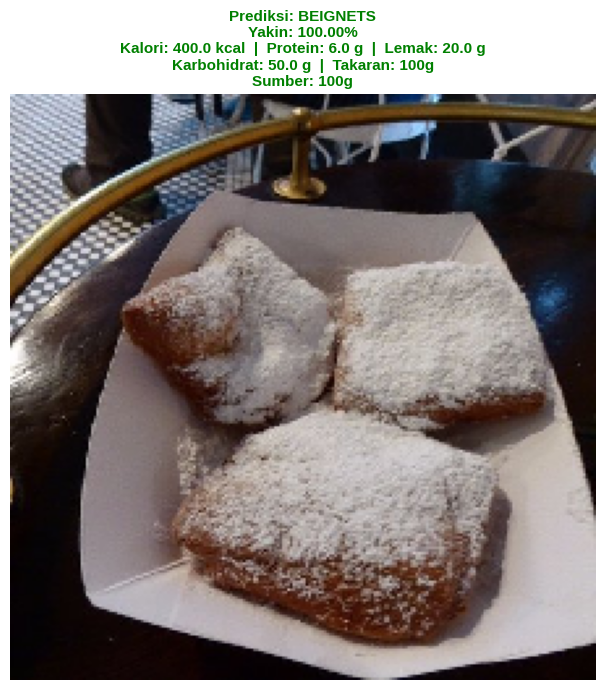


✅ File: beignets (2).jpg  →  beignets (100.00%)
📊 INFORMASI NUTRISI (per 100g):
   Kalori        : 400.0 kcal
   Protein       : 6.0 g
   Lemak         : 20.0 g
   Karbohidrat   : 50.0 g
   Takaran       : 100g
   Sumber        : 100g


In [ ]:
# @title 15. Uji Coba dengan Foto Asli (Upload Sendiri)
from google.colab import files
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def _fmt(val):
    """Format nilai nutrisi: '-' untuk kosong/None, value apa adanya untuk lainnya."""
    if val is None or val == "" or val == "-":
        return "-"
    return val

def predict_custom_image():
    print("📸 Silakan Upload Foto Makanan dari Komputer Anda...")
    uploaded = files.upload()

    if not uploaded:
        print("⚠️ Tidak ada file yang diupload.")
        return

    for fn in uploaded.keys():
        path = fn
        try:
            img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
            x = tf.keras.utils.img_to_array(img)
            x = np.expand_dims(x, axis=0)

            predictions = model.predict(x, verbose=0)

            pred_idx = np.argmax(predictions[0])
            pred_label = loaded_class_names[pred_idx]
            confidence = np.max(predictions[0]) * 100

            # Ambil seluruh field nutrisi dari nutrition_db
            info = nutrition_db.get(pred_label, {})
            kalori      = _fmt(info.get('kalori'))
            protein     = _fmt(info.get('protein'))
            lemak       = _fmt(info.get('lemak'))
            karbohidrat = _fmt(info.get('karbohidrat'))
            takaran     = _fmt(info.get('takaran'))
            sumber      = _fmt(info.get('sumber_takaran'))

            # --- Susun title: prediksi + confidence + seluruh info nutrisi ---
            title_lines = [
                f"Prediksi: {pred_label.replace('_', ' ').upper()}",
                f"Yakin: {confidence:.2f}%",
            ]
            if info and kalori != "-":
                title_lines.append(
                    f"Kalori: {kalori} kcal  |  Protein: {protein} g  |  Lemak: {lemak} g"
                )
                title_lines.append(
                    f"Karbohidrat: {karbohidrat} g  |  Takaran: {takaran}"
                )
                title_lines.append(f"Sumber: {sumber}")
            else:
                title_lines.append("(Data nutrisi tidak tersedia)")

            plt.figure(figsize=(7, 7))
            plt.imshow(img)
            plt.axis('off')
            plt.title(
                "\n".join(title_lines),
                color='green' if confidence > 70 else 'red',
                fontsize=11, fontweight='bold'
            )
            plt.tight_layout()
            plt.show()

            # --- Print log nutrisi lengkap ke console ---
            print(f"\n✅ File: {fn}  →  {pred_label} ({confidence:.2f}%)")
            if info and kalori != "-":
                print(f"📊 INFORMASI NUTRISI (per 100g):")
                print(f"   Kalori        : {kalori} kcal")
                print(f"   Protein       : {protein} g")
                print(f"   Lemak         : {lemak} g")
                print(f"   Karbohidrat   : {karbohidrat} g")
                print(f"   Takaran       : {takaran}")
                print(f"   Sumber        : {sumber}")
            else:
                print(f"⚠️  Data nutrisi untuk '{pred_label}' tidak tersedia di nutrition_db.")

        except Exception as e:
            print(f"❌ Gagal memproses gambar {fn}: {e}")

predict_custom_image()

In [ ]:
# @title 16. Cek Spesifikasi Lingkungan (Clean Output & Save to Drive)
import sys
import platform
import subprocess
import os
import logging

# --- SILENCE LOGS (Membungkam Iklan YDF) ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF logs
logging.getLogger('tensorflow').setLevel(logging.ERROR)
# Mematikan stdout sementara saat import tensorflowjs agar bersih
from contextlib import redirect_stdout, redirect_stderr
import io

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    import tensorflow as tf
    try:
        import tf_keras
    except: pass
    try:
        import tensorflowjs
    except: pass

print("="*60)
print("📋 SPESIFIKASI LINGKUNGAN PENGEMBANGAN")
print("="*60)

print(f"✅ Python Version      : {sys.version.split()[0]}")
print(f"✅ TensorFlow          : {tf.__version__}")
print(f"✅ Keras (Native)      : {tf.keras.__version__}")

if 'tf_keras' in sys.modules:
    print(f"✅ TF-Keras (Legacy)   : {tf_keras.__version__}")

if 'tensorflowjs' in sys.modules:
    print(f"✅ TensorFlow.js Conv. : {tensorflowjs.__version__}")

print("-" * 60)
print("📝 Membuat file requirements.txt...")

# PATH TUJUAN (LANGSUNG KE DRIVE)
REQ_PATH = os.path.join(MODELS_DIR, 'requirements.txt')

try:
    reqs = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'])
    with open(REQ_PATH, 'wb') as f:
        f.write(reqs)
    print(f"✅ SUKSES! File tersimpan di Google Drive.")
    print(f"📂 Lokasi: {REQ_PATH}")
except Exception as e:
    print(f"❌ Gagal: {e}")

📋 SPESIFIKASI LINGKUNGAN PENGEMBANGAN
✅ Python Version      : 3.12.13
✅ TensorFlow          : 2.19.0
✅ Keras (Native)      : 3.13.2
✅ TF-Keras (Legacy)   : 2.19.0
✅ TensorFlow.js Conv. : 4.22.0
------------------------------------------------------------
📝 Membuat file requirements.txt...
✅ SUKSES! File tersimpan di Google Drive.
📂 Lokasi: /content/drive/MyDrive/Skripsi/Deep_Learning/models/requirements.txt
